<a href="https://colab.research.google.com/github/camilodel02/Supervised-Learning/blob/main/Scholastic_Travel_Company/SVM_CamiloDelgado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Binary Classification in Python

##Caso de estudio en clase: Modeling as Scholastic Travel Company (A)

##1. Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, confusion_matrix, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Lectura de dataset
path = "/content/drive/MyDrive/Analítica 2/Datasets/03 CSV data -- STC(A)_numerical dates.csv"
df = pd.read_csv(path, header = 0, encoding="ISO-8859-1") #, encoding = "ISO-8859-1")
df.head()

,ID,Program.Code,From.Grade,To.Grade,Group.State,Is.Non.Annual.,Days,Travel.Type,Departure.Date,Return.Date,...,GroupGradeTypeLow,GroupGradeTypeHigh,GroupGradeType,MajorProgramCode,SingleGradeTripFlag,FPP.to.School.enrollment,FPP.to.PAX,Num.of.Non_FPP.PAX,SchoolSizeIndicator,Retained.in.2012.
0,1,HS,4.0,4.0,CA,0,1,A,40557,40557,...,K,Elementary,K->Elementary,H,1,0.063646,0.936508,4,L,1
1,2,HC,8.0,8.0,AZ,0,7,A,40557,40564,...,Middle,Middle,Middle->Middle,H,1,0.025882,0.880000,3,L,1
2,3,HD,8.0,8.0,FL,0,3,A,40558,40560,...,Middle,Middle,Middle->Middle,H,1,0.025131,0.888889,3,L,1
3,4,HN,9.0,12.0,VA,1,3,B,40558,40560,...,Undefined,Undefined,Undefined->Undefined,H,0,NaN,1.000000,0,NaN,0
4,5,HD,6.0,8.0,FL,0,6,T,40559,40564,...,Middle,Middle,Middle->Middle,H,0,0.112500,0.910112,8,M-L,0


##2. EDA

###2.1 Métricas generales del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2389 non-null   int64  
 1   Program.Code                    2389 non-null   object 
 2   From.Grade                      2262 non-null   float64
 3   To.Grade                        2239 non-null   float64
 4   Group.State                     2389 non-null   object 
 5   Is.Non.Annual.                  2389 non-null   int64  
 6   Days                            2389 non-null   int64  
 7   Travel.Type                     2389 non-null   object 
 8   Departure.Date                  2389 non-null   int64  
 9   Return.Date                     2389 non-null   int64  
 10  Deposit.Date                    2389 non-null   int64  
 11  Special.Pay                     470 non-null    object 
 12  Tuition                         23

In [ ]:
df.describe()

,ID,From.Grade,To.Grade,Is.Non.Annual.,Days,Departure.Date,Return.Date,Deposit.Date,Tuition,FRP.Active,...,NumberOfMeetingswithParents,FirstMeeting,LastMeeting,DifferenceTraveltoFirstMeeting,DifferenceTraveltoLastMeeting,SingleGradeTripFlag,FPP.to.School.enrollment,FPP.to.PAX,Num.of.Non_FPP.PAX,Retained.in.2012.
count,2389.000000,2262.000000,2239.000000,2389.000000,2389.000000,2389.000000,2389.000000,2389.000000,2389.000000,2389.000000,...,2389.000000,2052.000000,2052.000000,2052.000000,2052.000000,2389.000000,2298.000000,2389.000000,2389.000000,2389.000000
mean,1195.000000,7.268347,7.912908,0.154039,4.575136,40670.764337,40674.498535,40475.821264,1615.217664,16.867727,...,1.102135,40408.495614,40441.601365,262.083821,228.978070,0.556718,0.066184,0.900667,2.953537,0.607367
std,689.789219,1.388350,1.558226,0.361062,1.432128,35.217643,35.243691,37.906251,645.096047,16.942782,...,0.611544,72.393761,43.666436,79.520208,53.636014,0.496877,0.081112,0.049119,2.876422,0.488439
min,1.000000,3.000000,3.000000,0.000000,1.000000,40557.000000,40557.000000,40081.000000,79.000000,0.000000,...,0.000000,39945.000000,39945.000000,-204.000000,-204.000000,0.000000,0.000922,0.600000,0.000000,0.000000
25%,598.000000,7.000000,8.000000,0.000000,4.000000,40642.000000,40645.000000,40466.000000,1174.000000,6.000000,...,1.000000,40404.250000,40429.000000,208.000000,196.750000,0.000000,0.020787,0.882353,1.000000,0.000000
50%,1195.000000,8.000000,8.000000,0.000000,5.000000,40680.000000,40683.000000,40479.000000,1700.000000,12.000000,...,1.000000,40435.000000,40442.000000,250.000000,233.000000,1.000000,0.045256,0.909091,2.000000,1.000000
75%,1792.000000,8.000000,8.000000,0.000000,5.000000,40701.000000,40704.000000,40487.000000,2048.000000,23.000000,...,1.000000,40449.000000,40451.000000,287.000000,261.000000,1.000000,0.087517,0.933333,4.000000,1.000000
max,2389.000000,12.000000,12.000000,1.000000,12.000000,40724.000000,40729.000000,40846.000000,4200.000000,257.000000,...,2.000000,40821.000000,40821.000000,749.000000,749.000000,1.000000,2.052632,1.000000,47.000000,1.000000


In [ ]:
print("Shape del dataset:", df.shape)
print("\nTipos de datos:\n", df.dtypes)
print("\nValores nulos por variable:\n", df.isnull().sum().sort_values(ascending=False))
print("\nDuplicados:", df.duplicated().sum())

Shape del dataset: (2389, 56)

Tipos de datos:
 ID                                  int64
Program.Code                       object
From.Grade                        float64
To.Grade                          float64
Group.State                        object
Is.Non.Annual.                      int64
Days                                int64
Travel.Type                        object
Departure.Date                      int64
Return.Date                         int64
Deposit.Date                        int64
Special.Pay                        object
Tuition                             int64
FRP.Active                          int64
FRP.Cancelled                       int64
FRP.Take.up.percent.              float64
Early.RPL                         float64
Latest.RPL                        float64
Cancelled.Pax                       int64
Total.Discount.Pax                  int64
Initial.System.Date               float64
Poverty.Code                       object
Region                      

In [ ]:
df['Special.Pay'].value_counts()

,count
Special.Pay,
FR,293
SA,107
CP,70


In [ ]:
#Hay tipos de variables numéricas y no numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number, "datetime"]).columns.tolist()

print("\nVariables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)


Variables numéricas: ['ID', 'From.Grade', 'To.Grade', 'Is.Non.Annual.', 'Days', 'Departure.Date', 'Return.Date', 'Deposit.Date', 'Tuition', 'FRP.Active', 'FRP.Cancelled', 'FRP.Take.up.percent.', 'Early.RPL', 'Latest.RPL', 'Cancelled.Pax', 'Total.Discount.Pax', 'Initial.System.Date', 'CRM.Segment', 'Parent.Meeting.Flag', 'MDR.High.Grade', 'Total.School.Enrollment', 'EZ.Pay.Take.Up.Rate', 'School.Sponsor', 'FPP', 'Total.Pax', 'SPR.Group.Revenue', 'NumberOfMeetingswithParents', 'FirstMeeting', 'LastMeeting', 'DifferenceTraveltoFirstMeeting', 'DifferenceTraveltoLastMeeting', 'SingleGradeTripFlag', 'FPP.to.School.enrollment', 'FPP.to.PAX', 'Num.of.Non_FPP.PAX', 'Retained.in.2012.']
Variables categóricas: ['Program.Code', 'Group.State', 'Travel.Type', 'Special.Pay', 'Poverty.Code', 'Region', 'School.Type', 'MDR.Low.Grade', 'Income.Level', 'SPR.Product.Type', 'SPR.New.Existing', 'SchoolGradeTypeLow', 'SchoolGradeTypeHigh', 'SchoolGradeType', 'DepartureMonth', 'GroupGradeTypeLow', 'GroupGrade

In [ ]:
#Revisión de que variables numéricas tienen nulls --> servirá como insight para la imputación de valores despues
for col in num_cols:
  if df[col].isna().sum() > 0:
    print(f"Valores nulos en {col}: {df[col].isna().sum()}")

Valores nulos en From.Grade: 127
Valores nulos en To.Grade: 150
Valores nulos en Early.RPL: 673
Valores nulos en Latest.RPL: 19
Valores nulos en Initial.System.Date: 8
Valores nulos en CRM.Segment: 4
Valores nulos en MDR.High.Grade: 68
Valores nulos en Total.School.Enrollment: 91
Valores nulos en FirstMeeting: 337
Valores nulos en LastMeeting: 337
Valores nulos en DifferenceTraveltoFirstMeeting: 337
Valores nulos en DifferenceTraveltoLastMeeting: 337
Valores nulos en FPP.to.School.enrollment: 91


In [ ]:
#Revisión de que variables no numericas tienen nulls --> servirá como insight para la imputación de valores despues
for col in cat_cols:
  if df[col].isna().sum() > 0:
    print(f"Valores nulos en {col}: {df[col].isna().sum()}")

Valores nulos en Special.Pay: 1919
Valores nulos en Poverty.Code: 599
Valores nulos en MDR.Low.Grade: 68
Valores nulos en Income.Level: 62
Valores nulos en SchoolSizeIndicator: 91


###2.2 Insights de las variables numéricas

/tmp/ipython-input-3555898189.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,4))


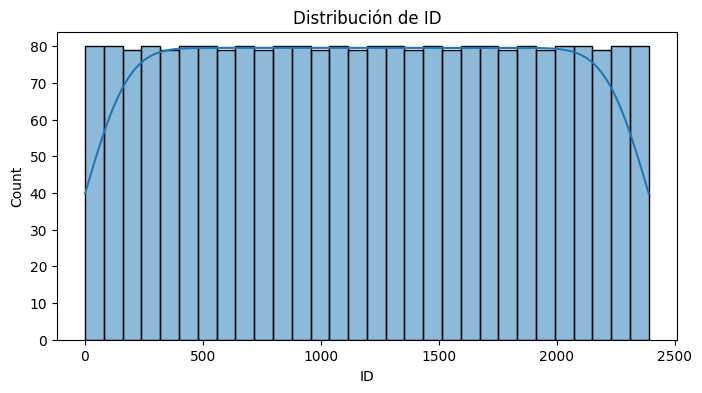

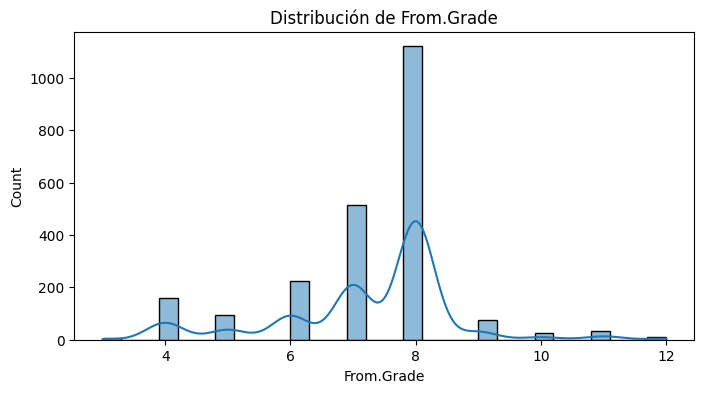

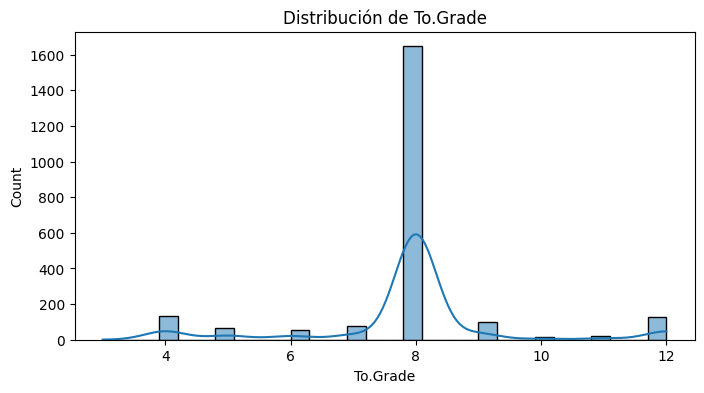

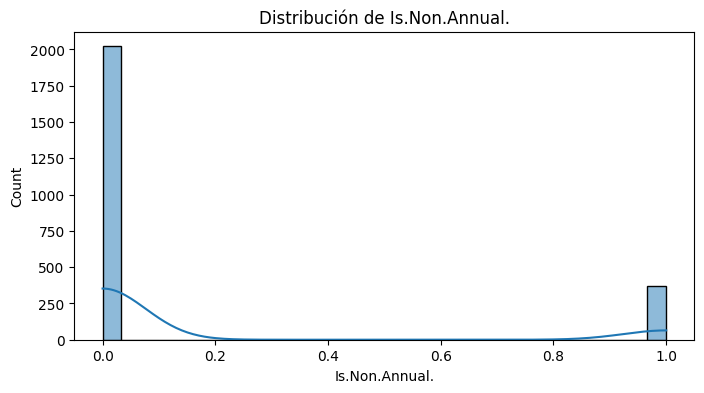

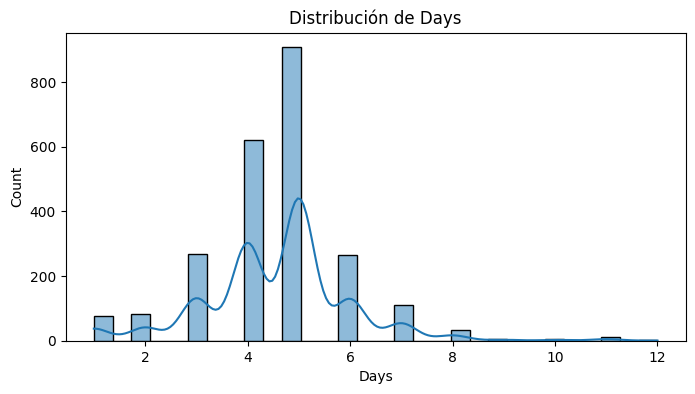

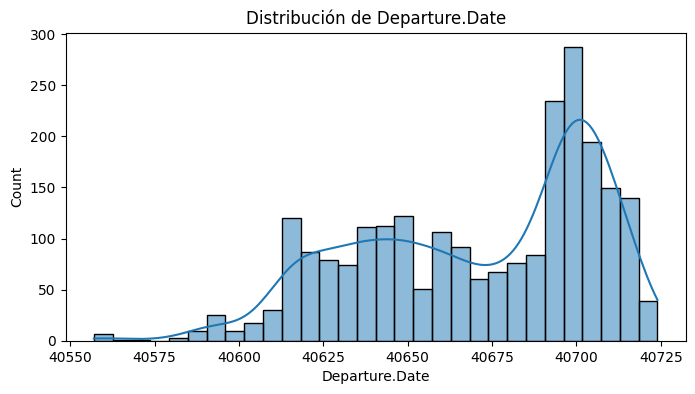

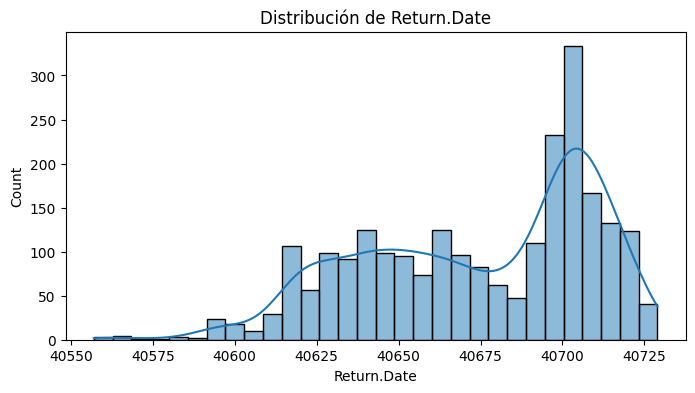

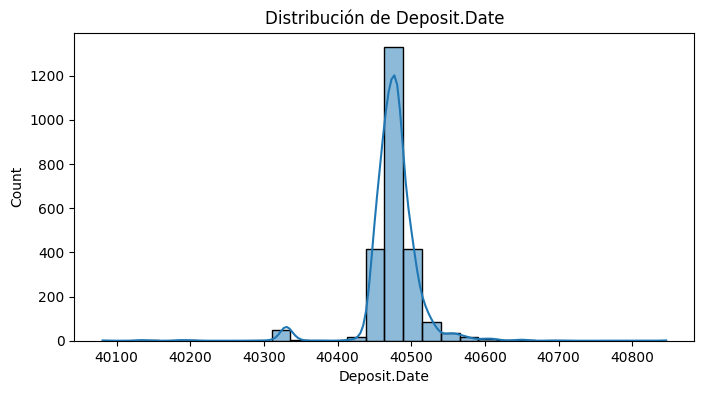

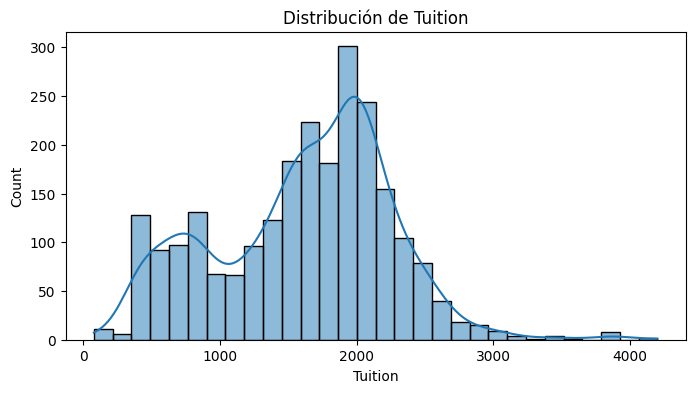

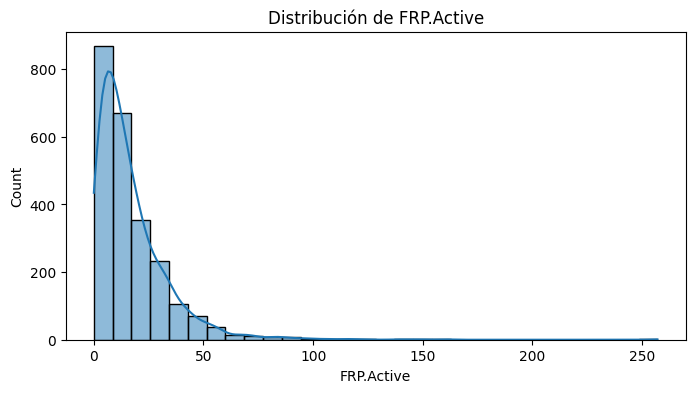

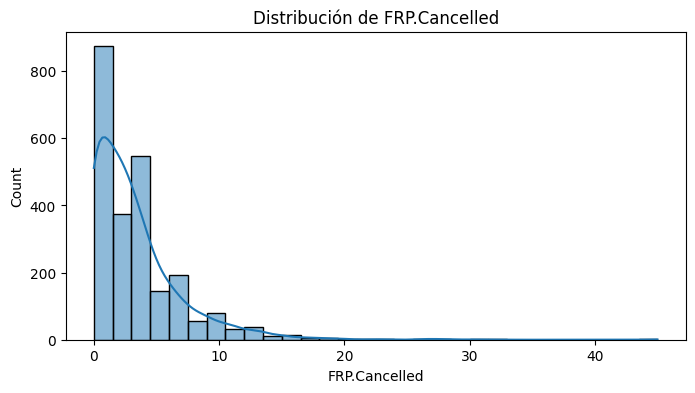

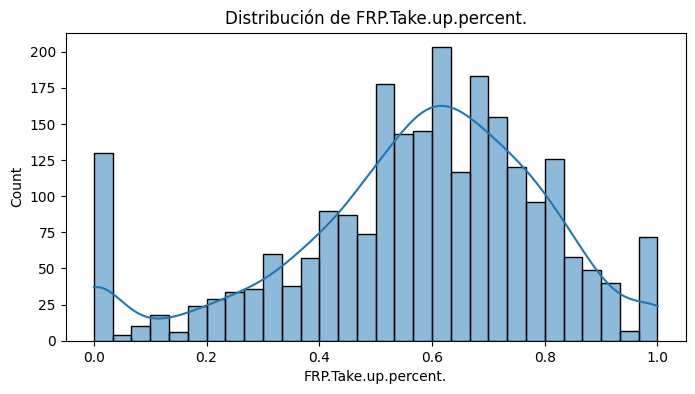

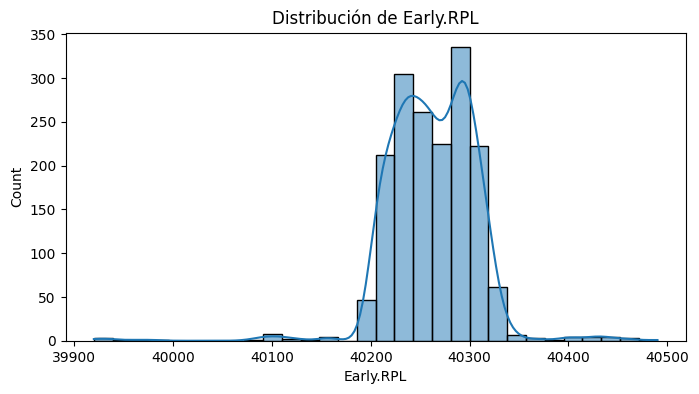

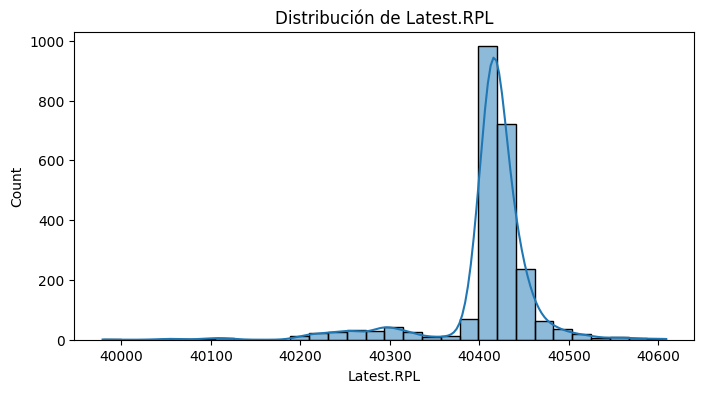

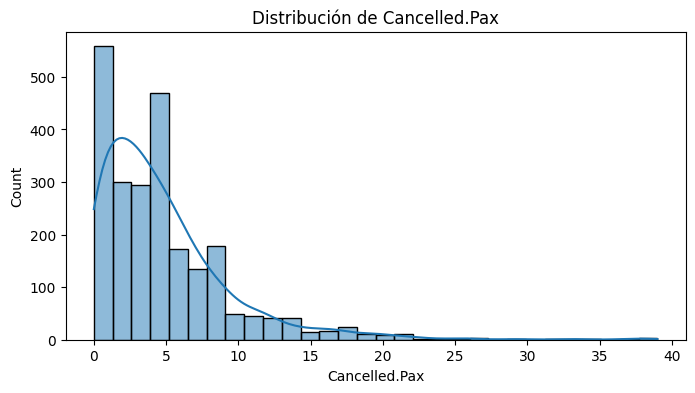

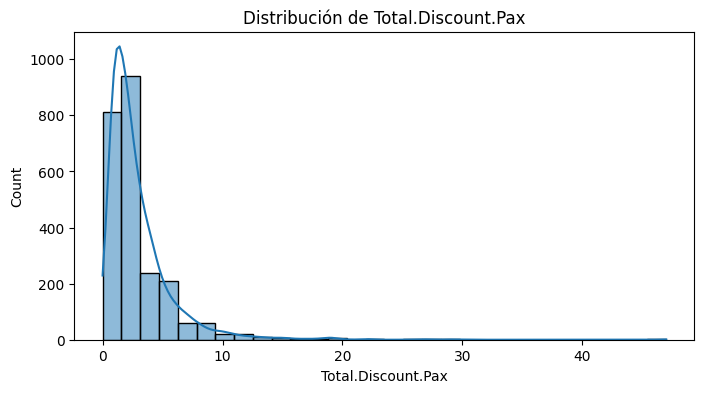

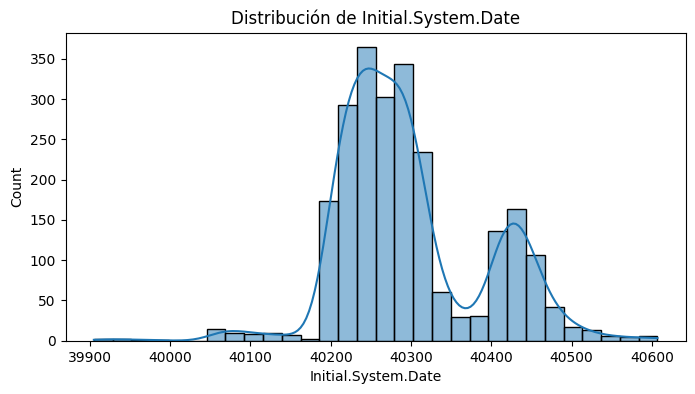

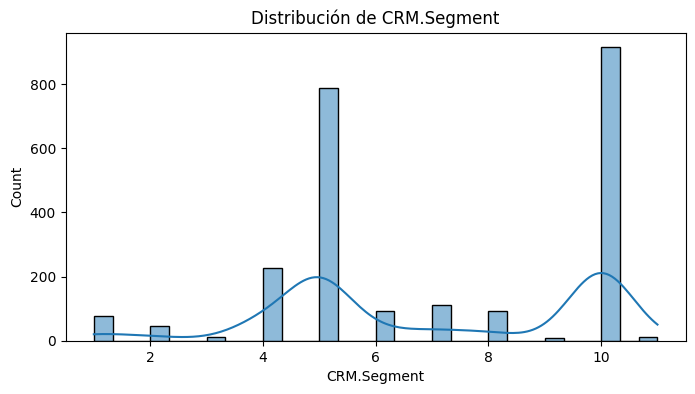

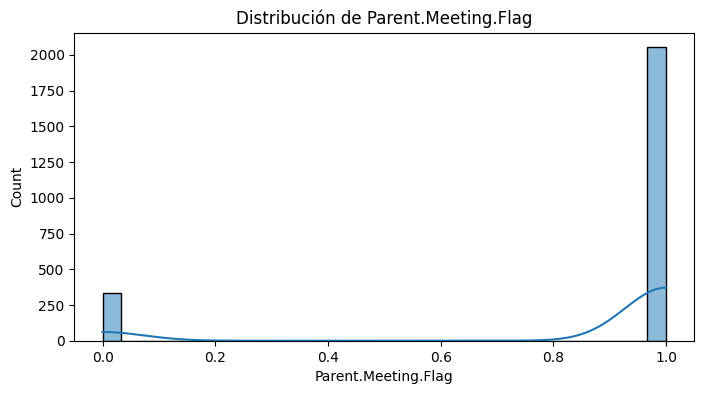

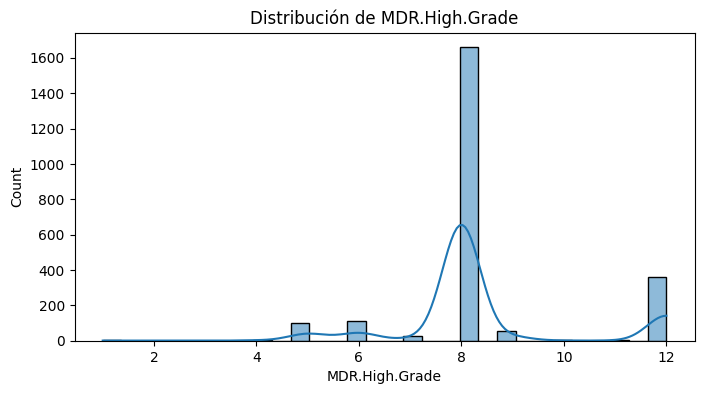

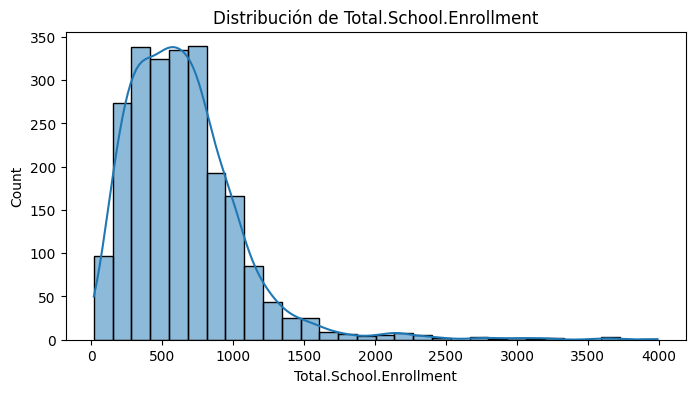

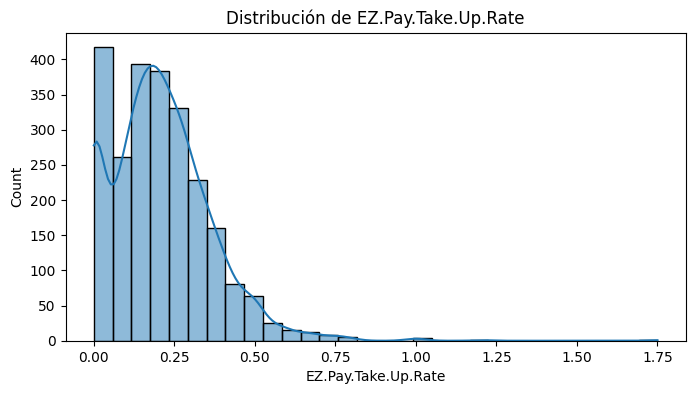

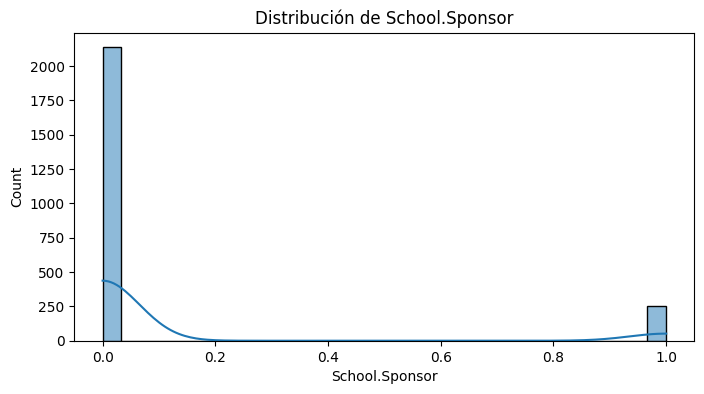

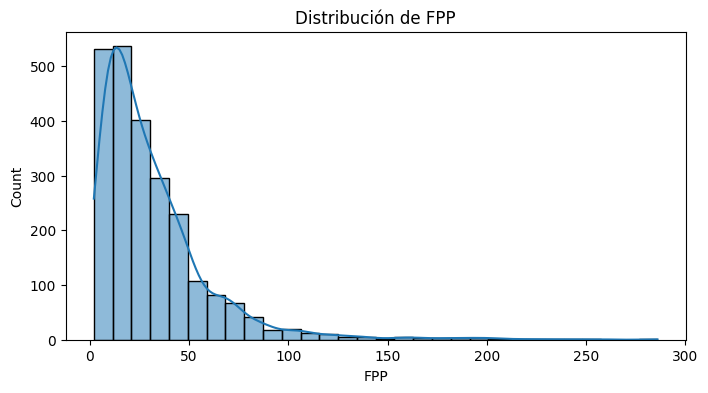

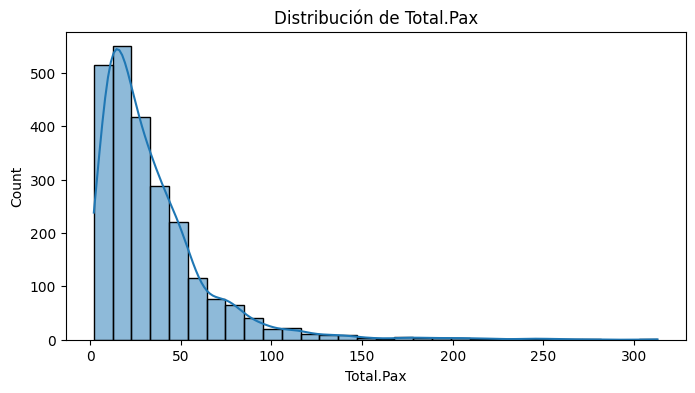

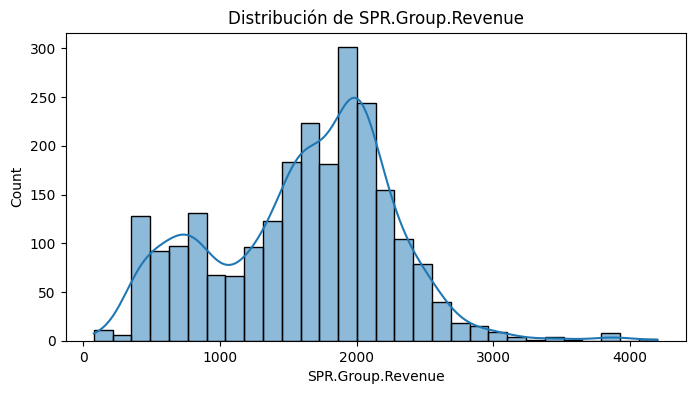

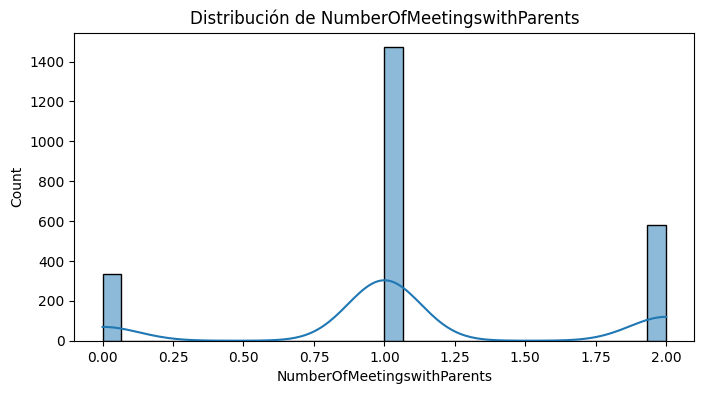

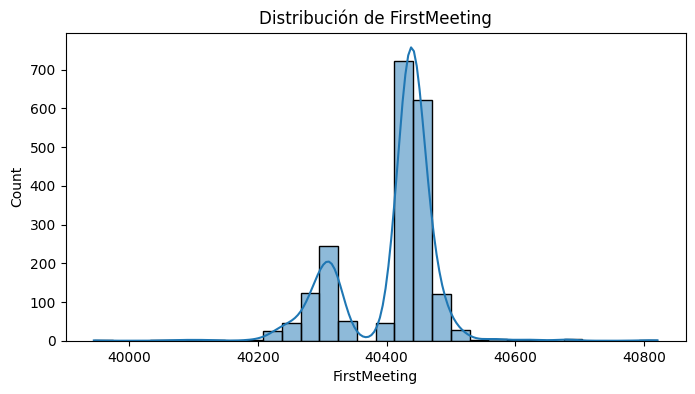

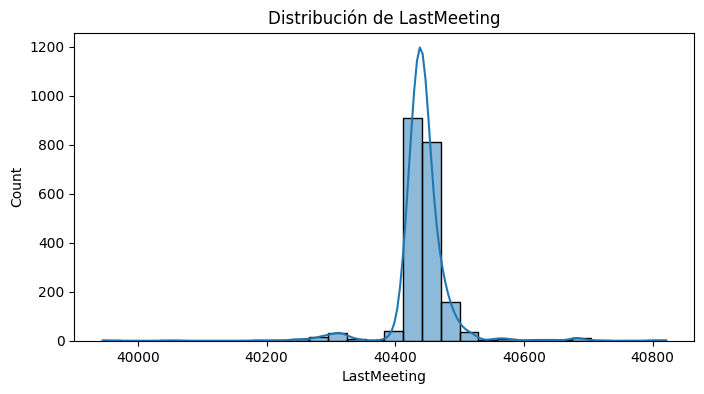

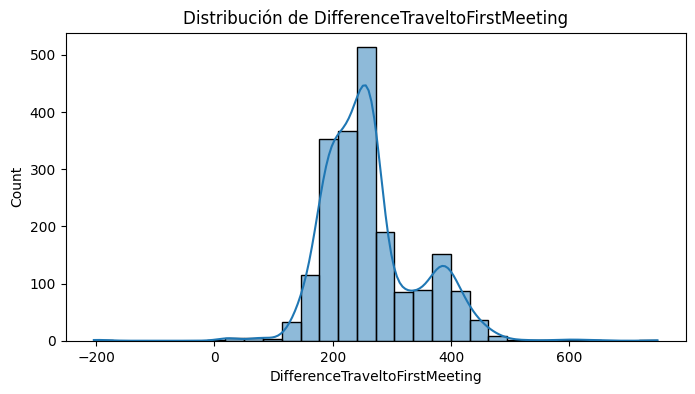

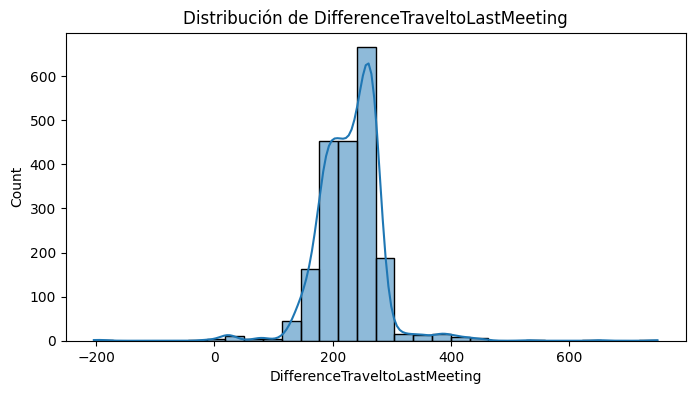

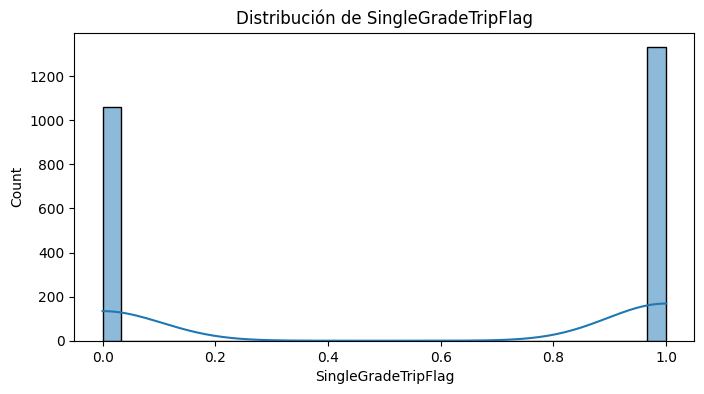

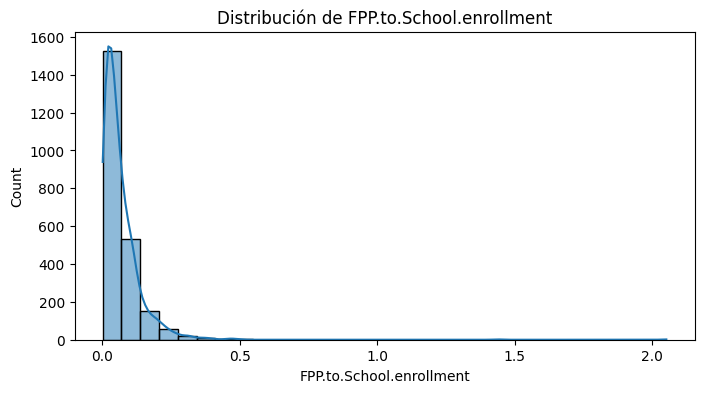

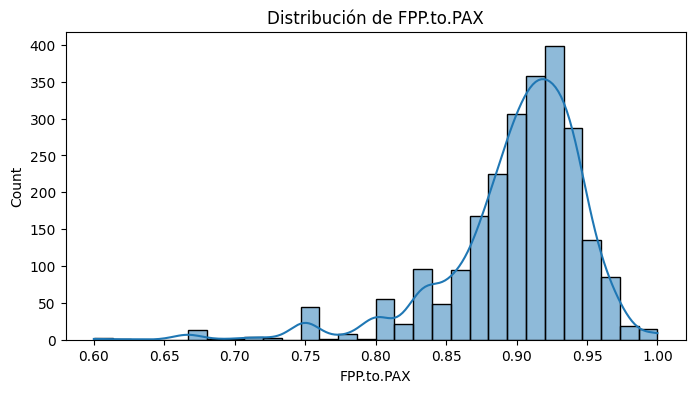

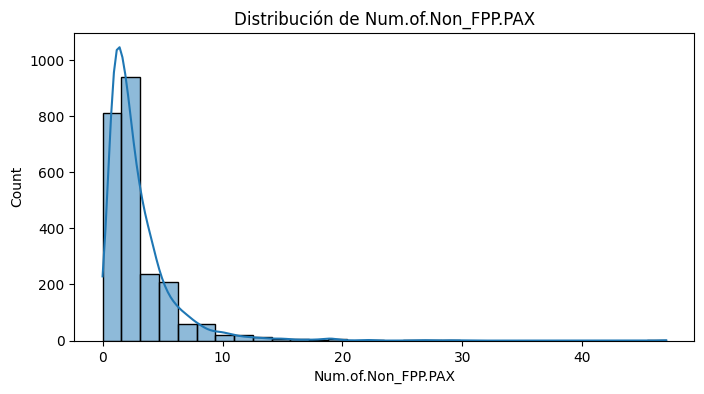

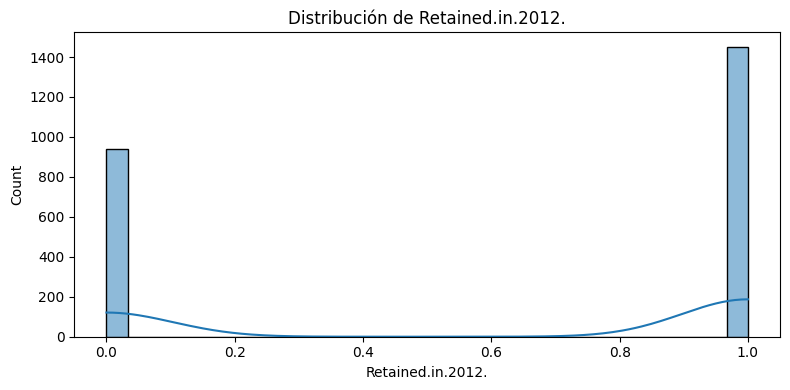

In [ ]:
#Disribucion de las variables numéricas
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

###2.3 Insights de las variables no numéricas

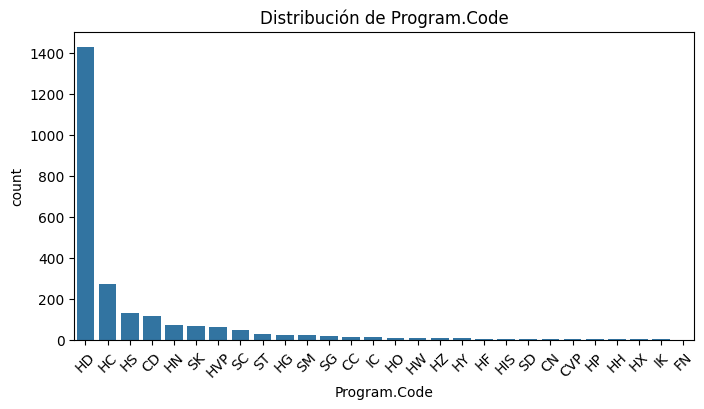

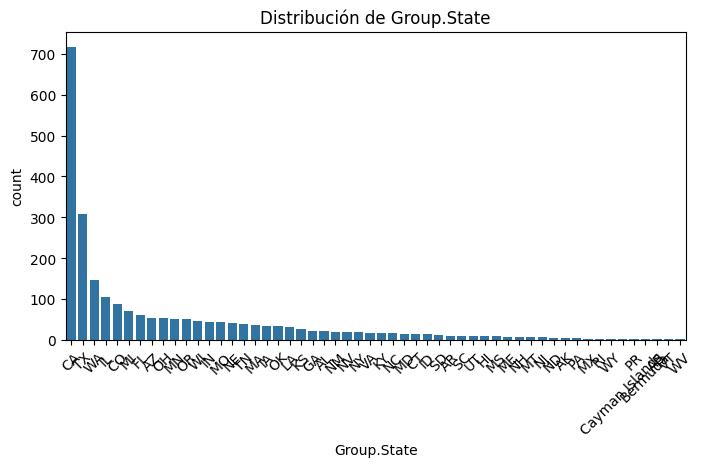

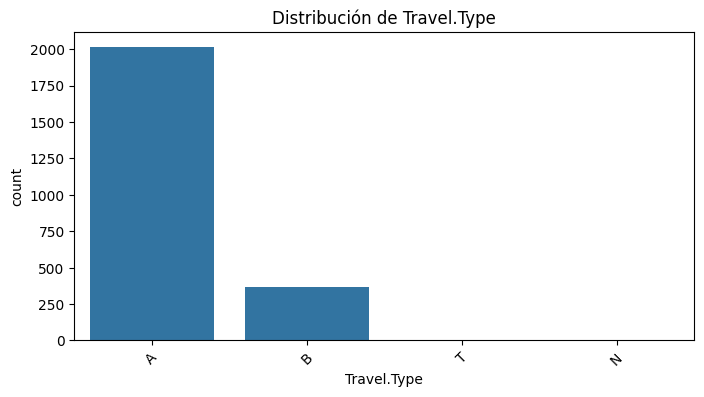

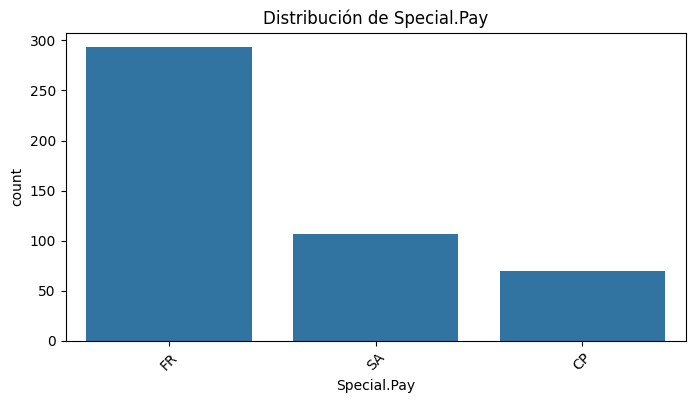

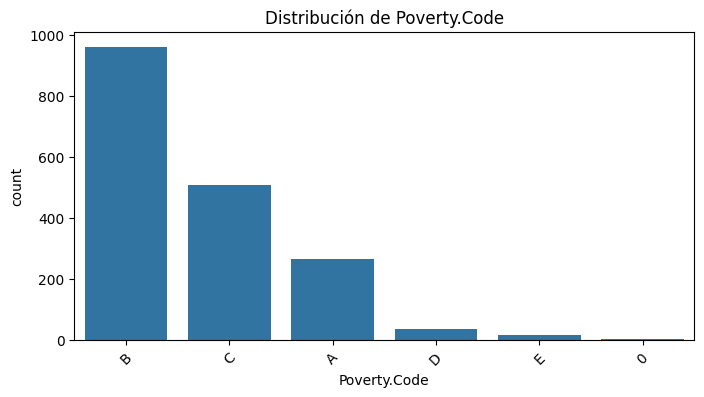

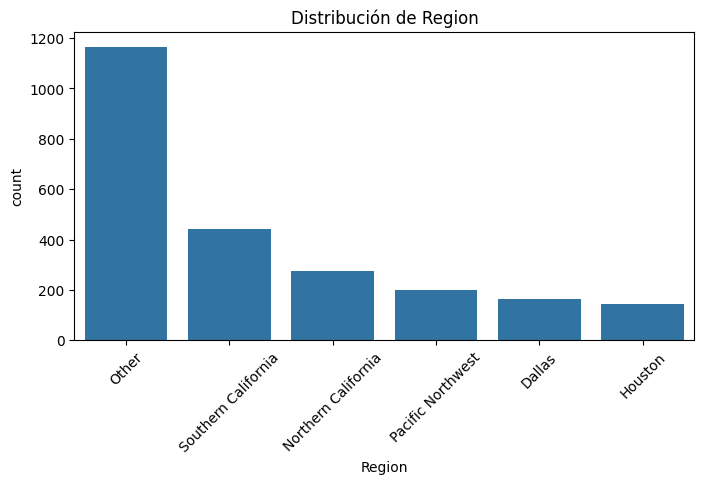

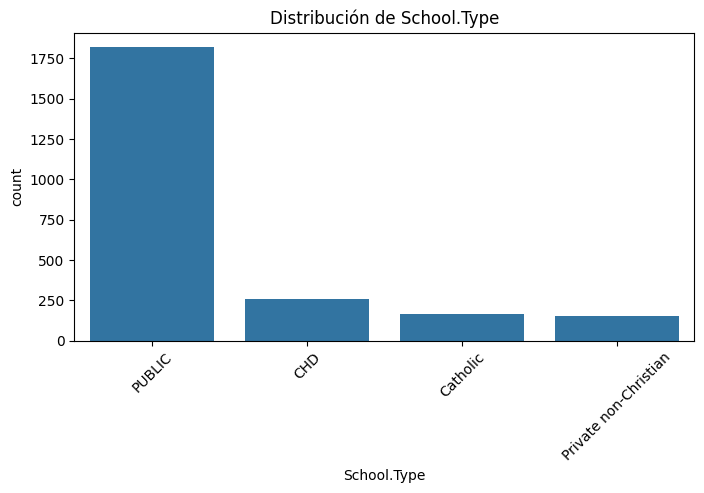

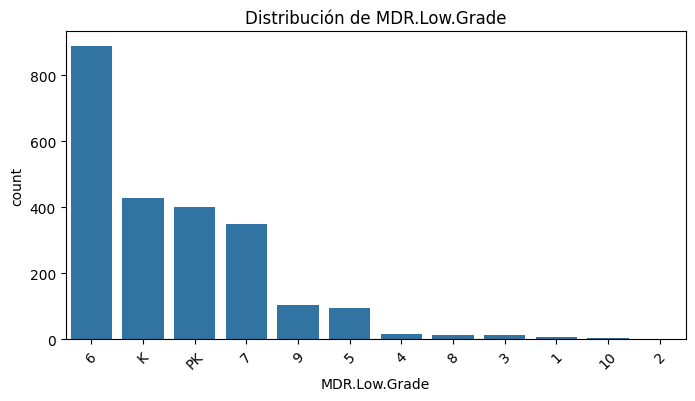

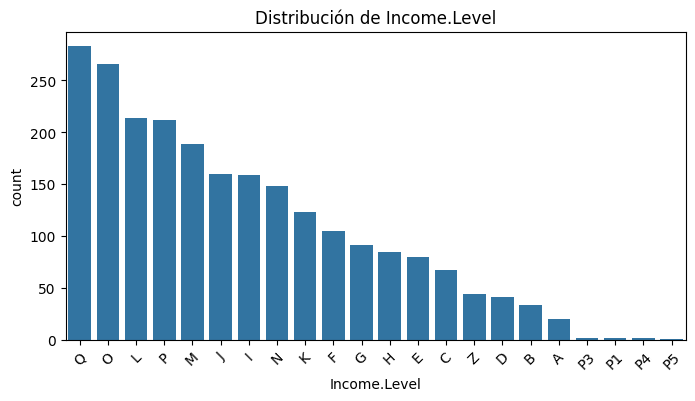

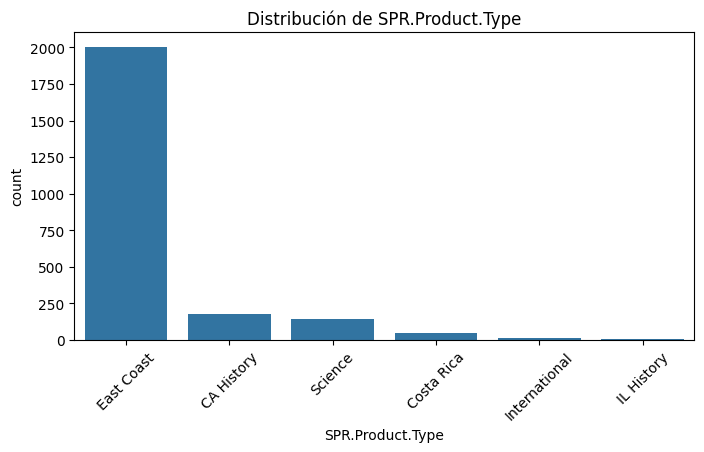

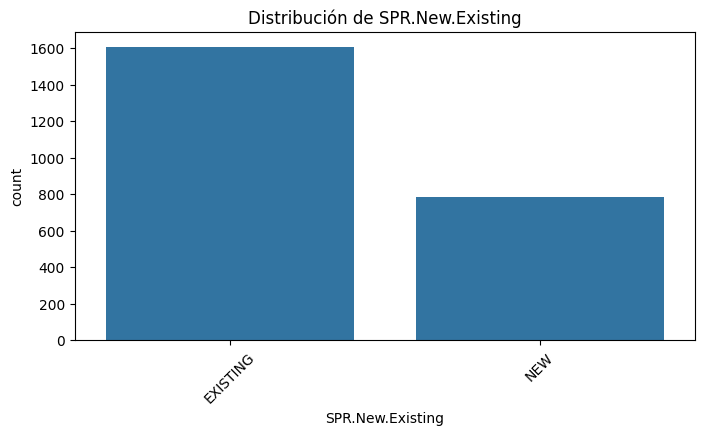

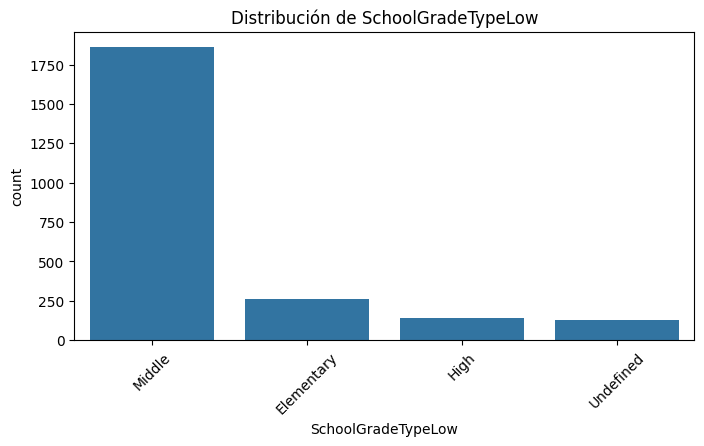

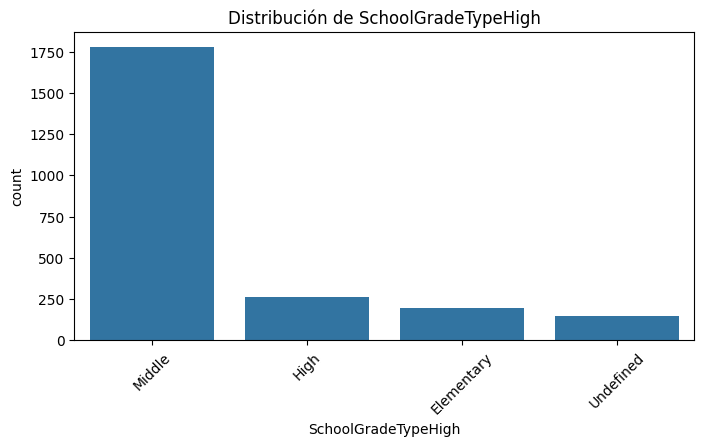

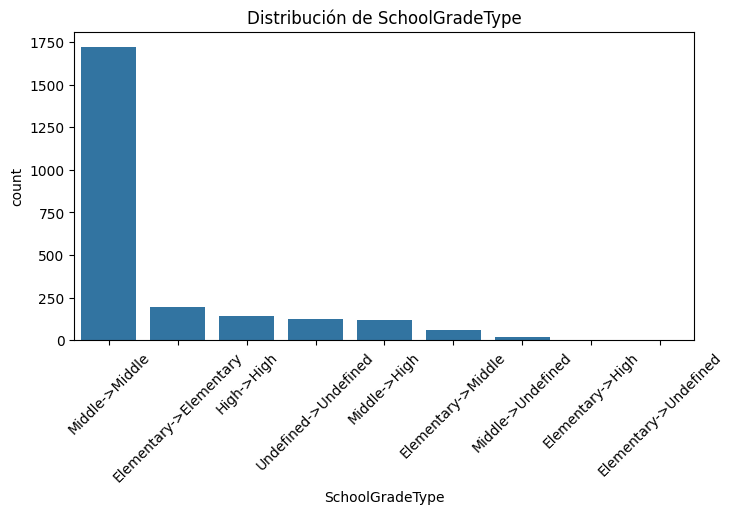

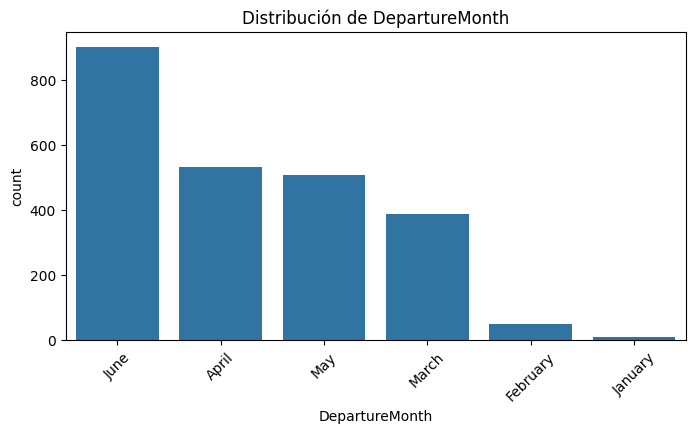

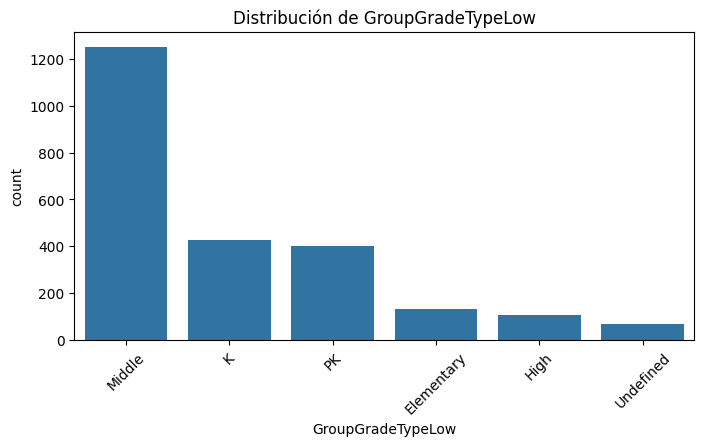

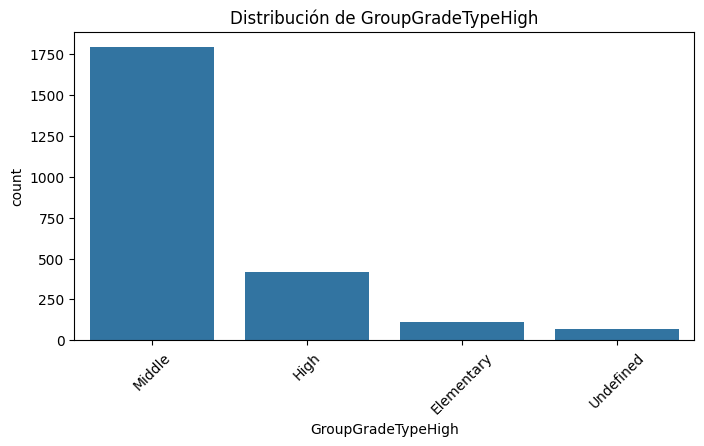

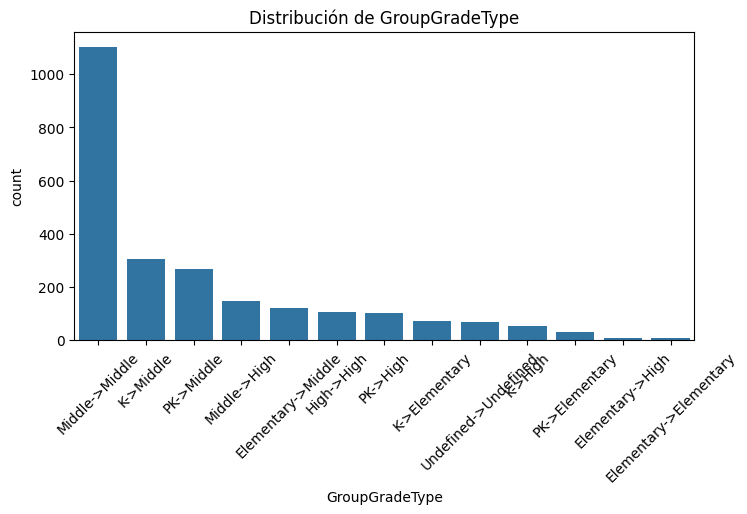

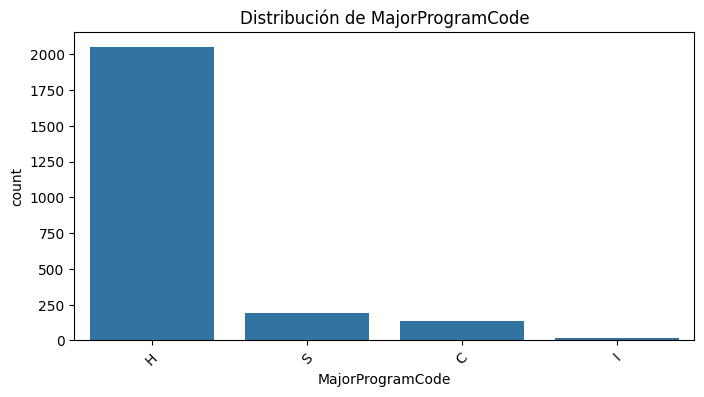

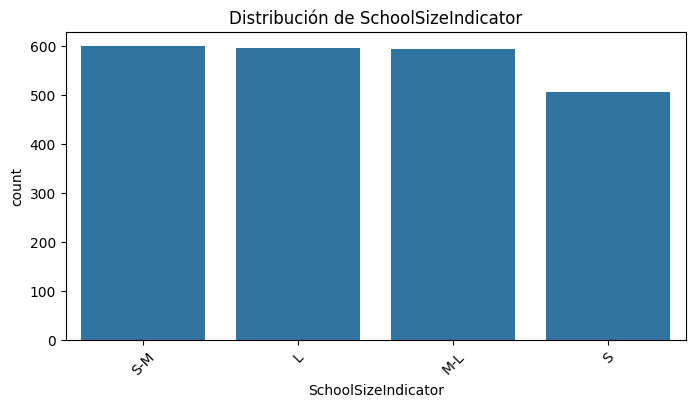

In [ ]:
#Distribución de las variables categóricas
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribución de {col}")
    plt.show()

###2.4 Analisis de la variable objetivo vs las demás variables


Distribución de la variable objetivo:
Retained.in.2012.
1    0.607367
0    0.392633
Name: proportion, dtype: float64


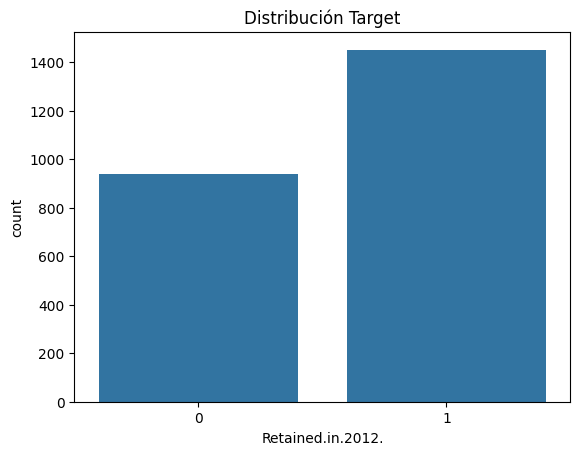

In [ ]:
target = "Retained.in.2012."
print("\nDistribución de la variable objetivo:")
print(df[target].value_counts(normalize=True))
sns.countplot(data=df, x=target)
plt.title("Distribución Target")
plt.show()

/tmp/ipython-input-1006498248.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,4))


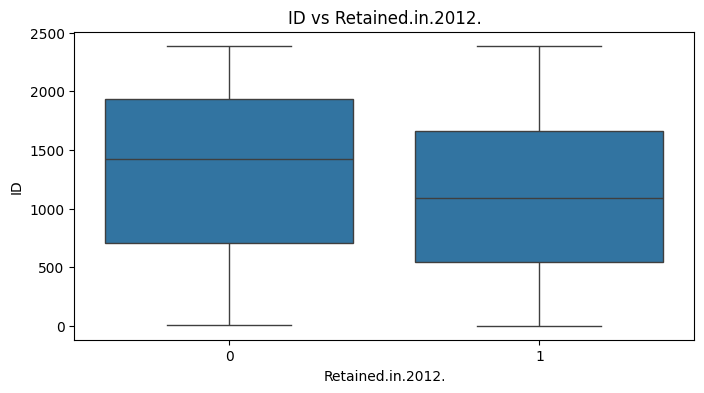

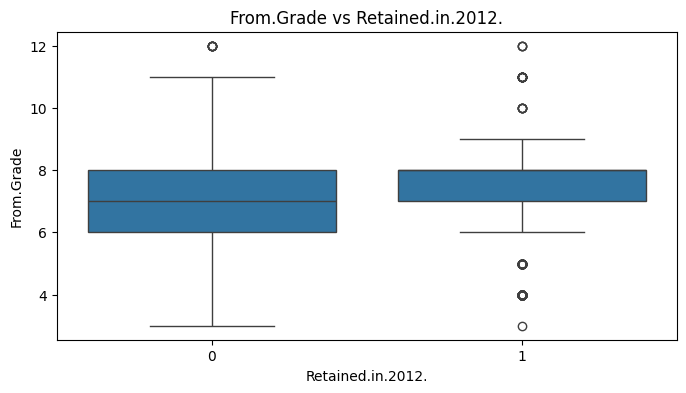

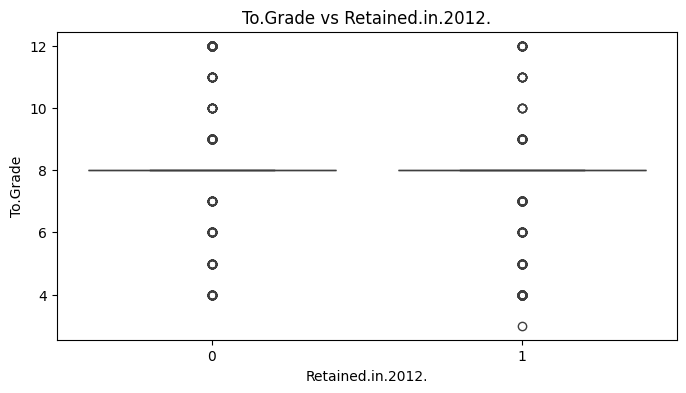

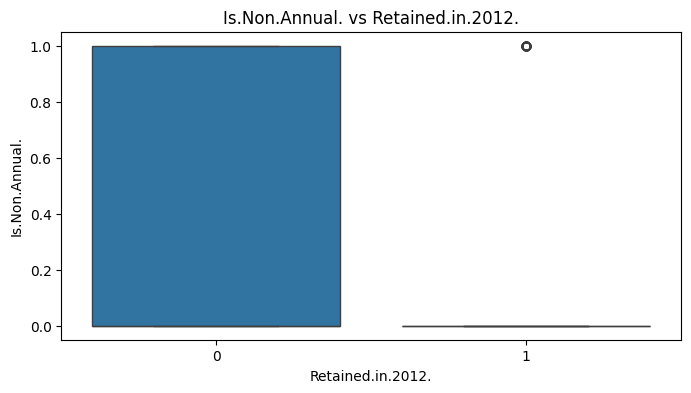

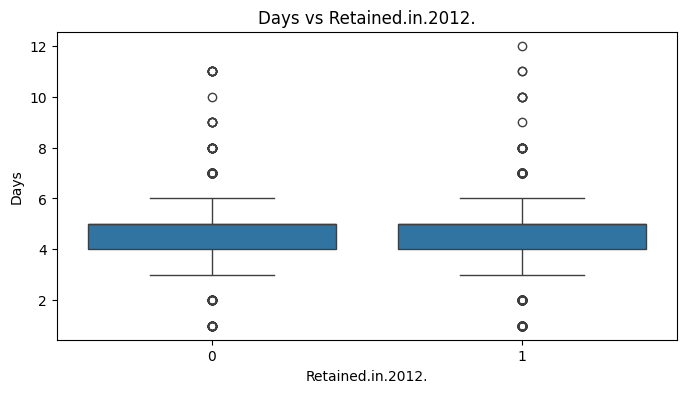

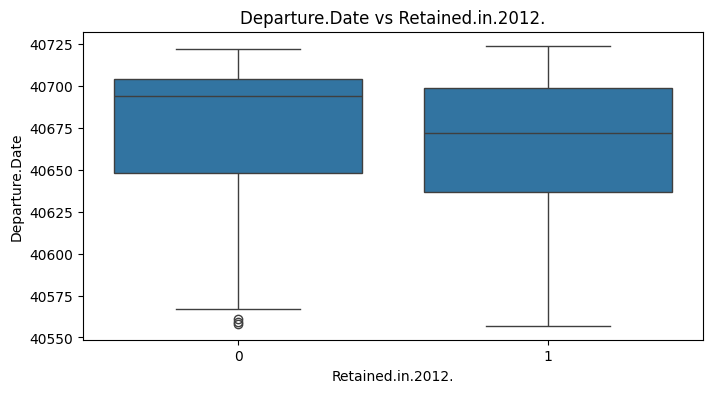

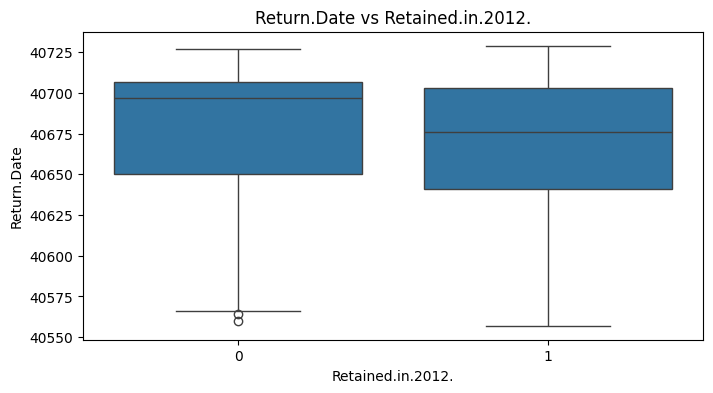

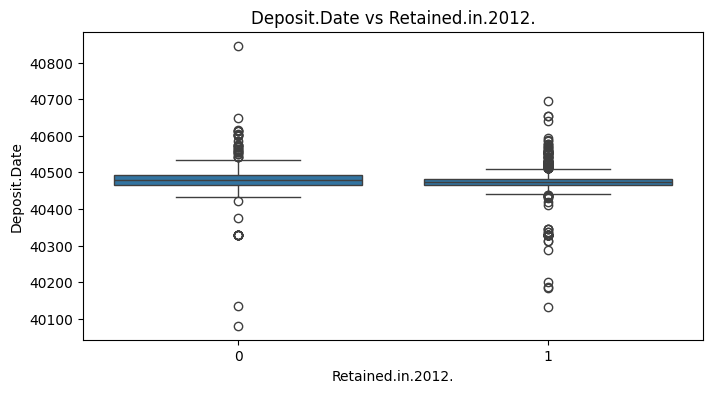

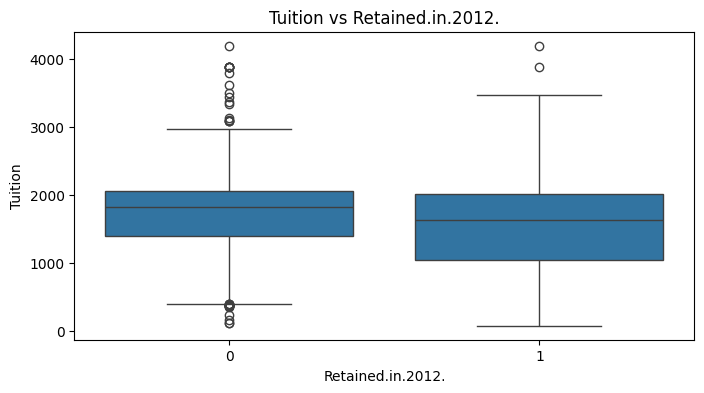

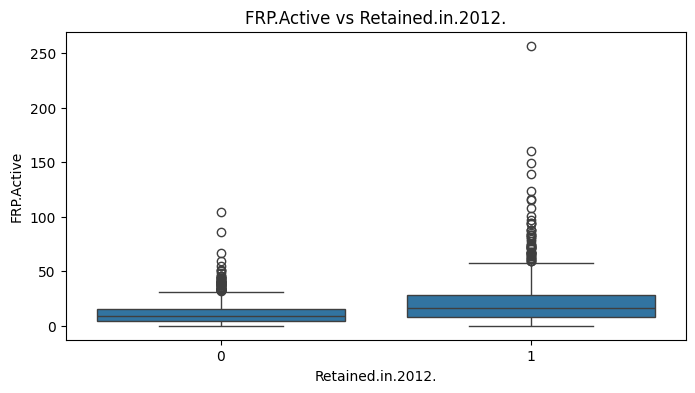

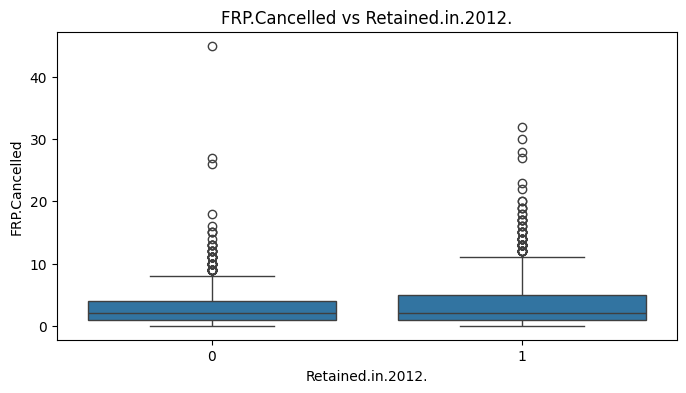

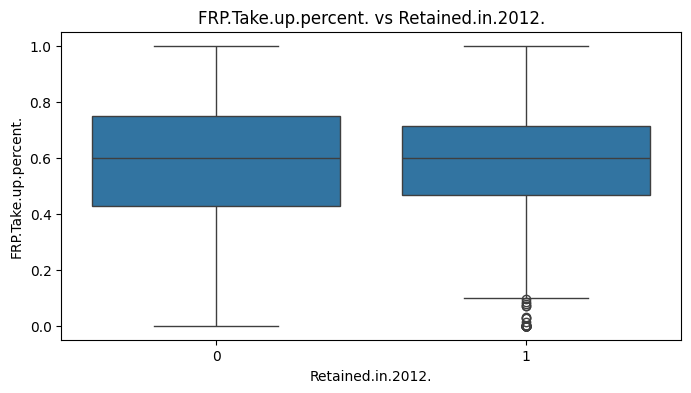

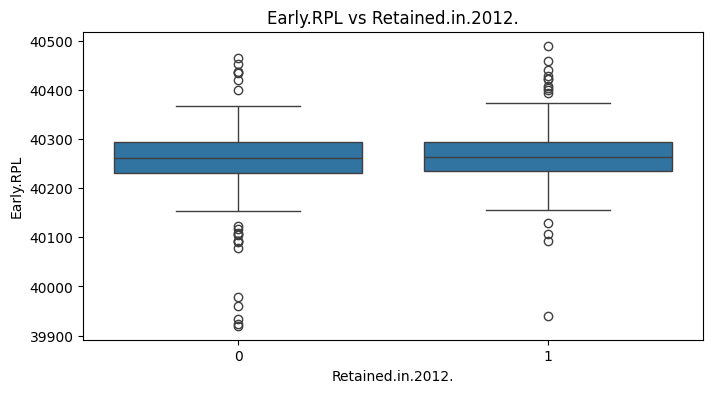

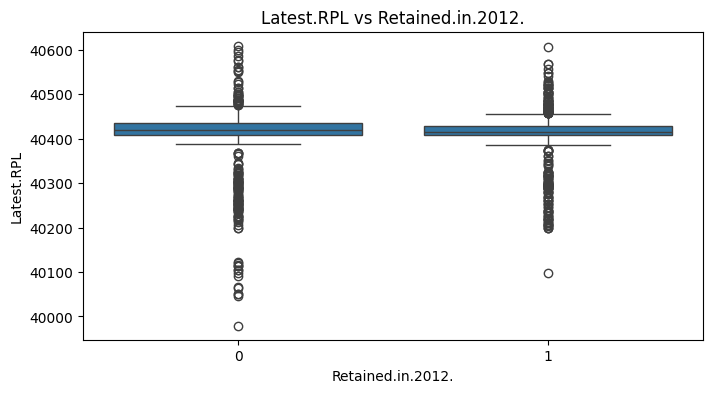

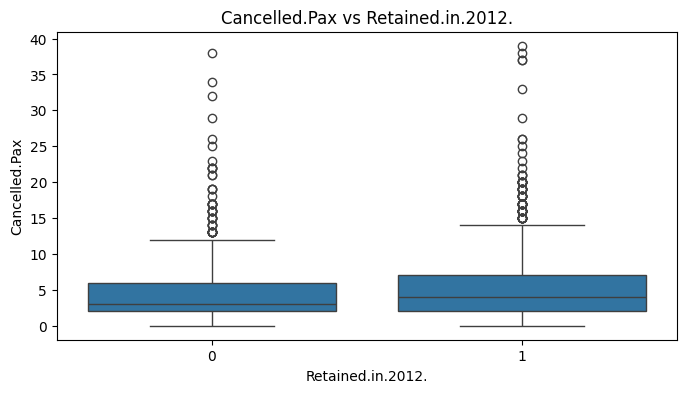

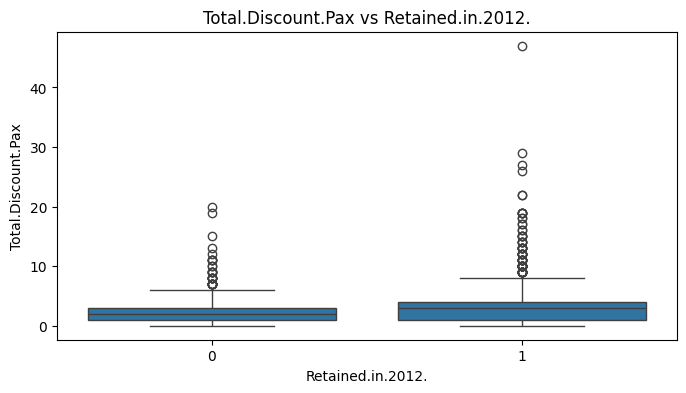

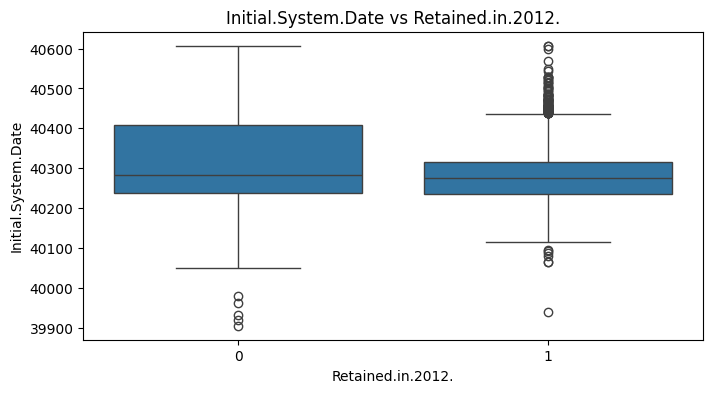

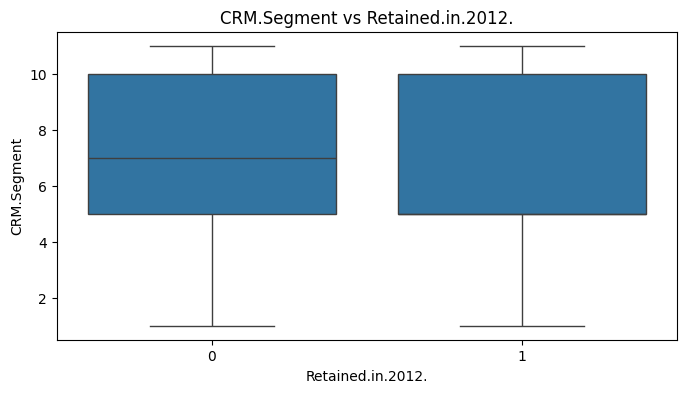

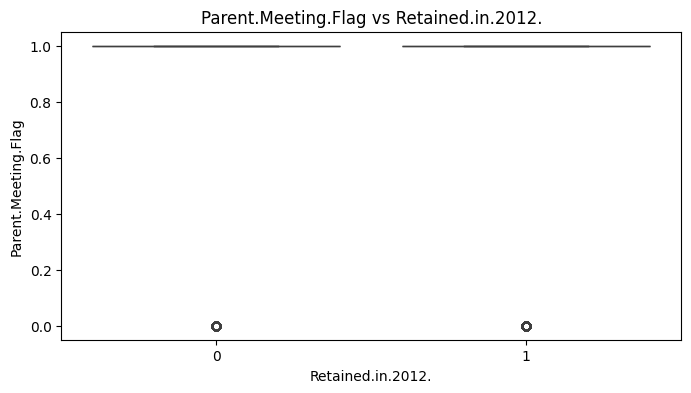

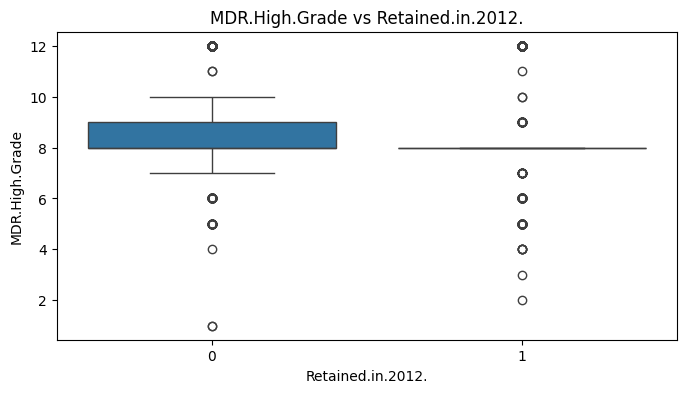

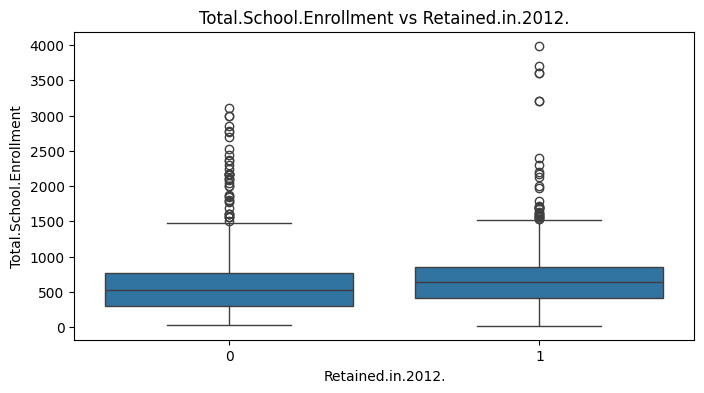

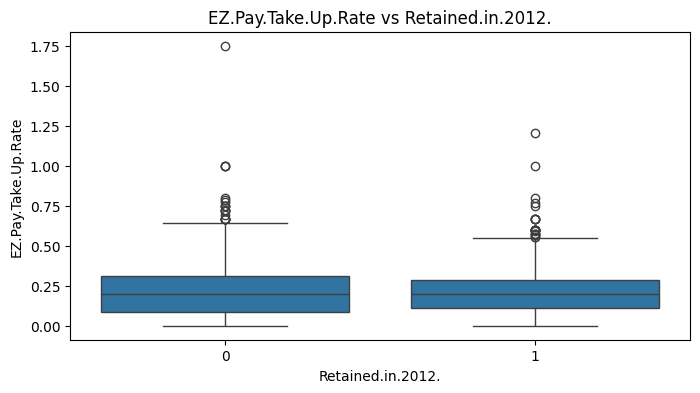

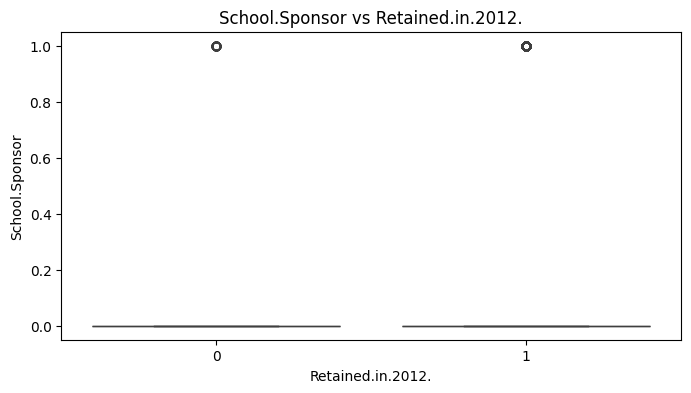

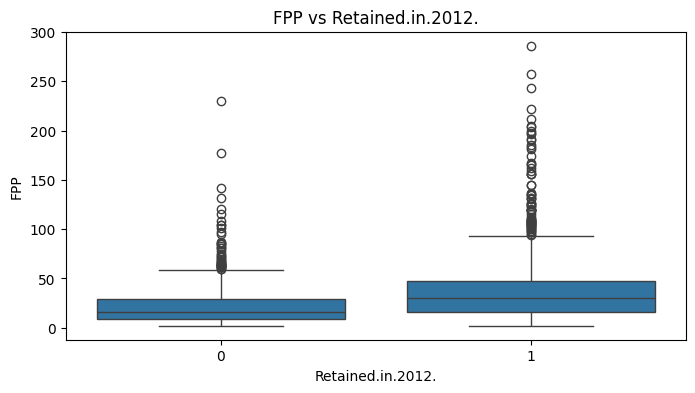

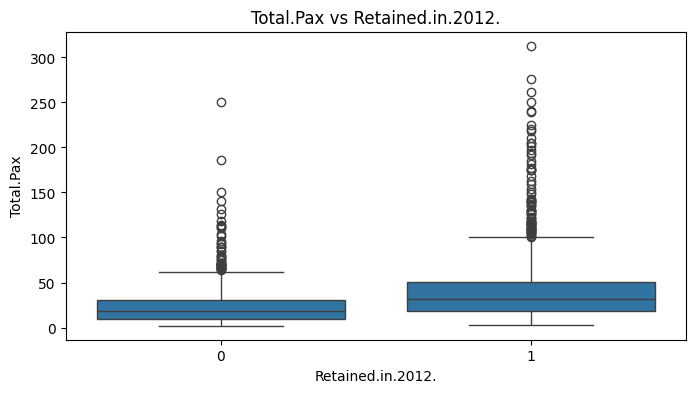

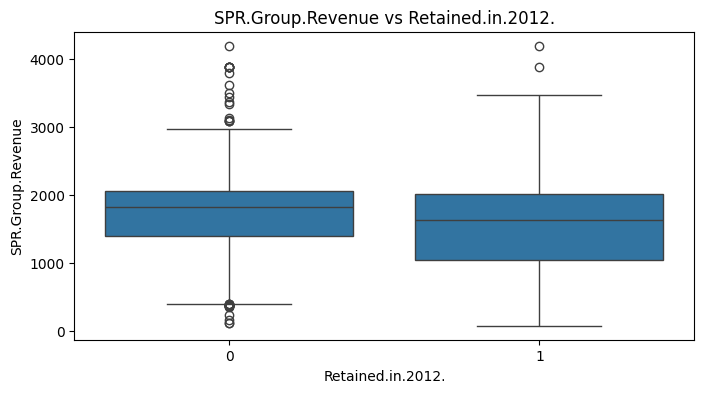

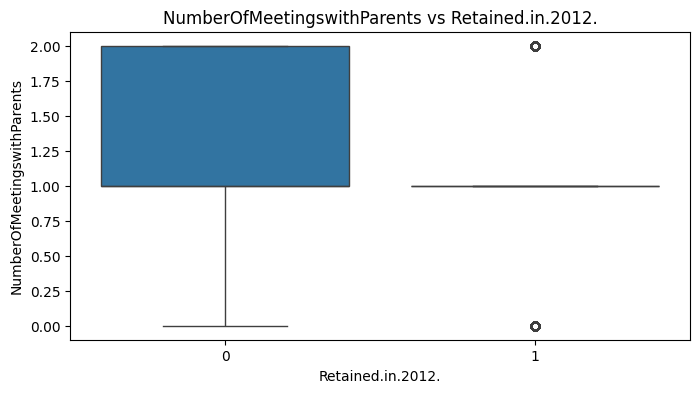

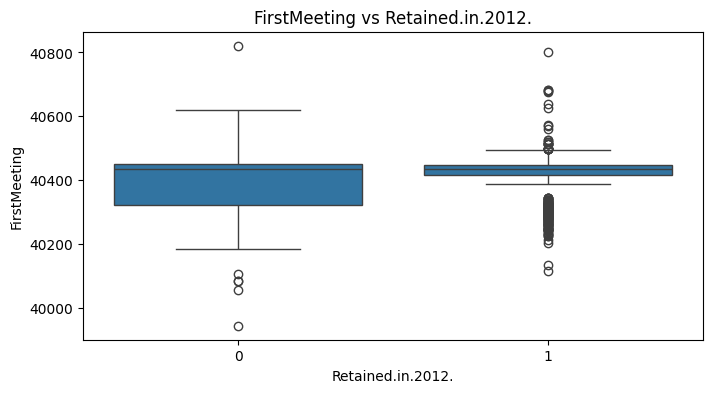

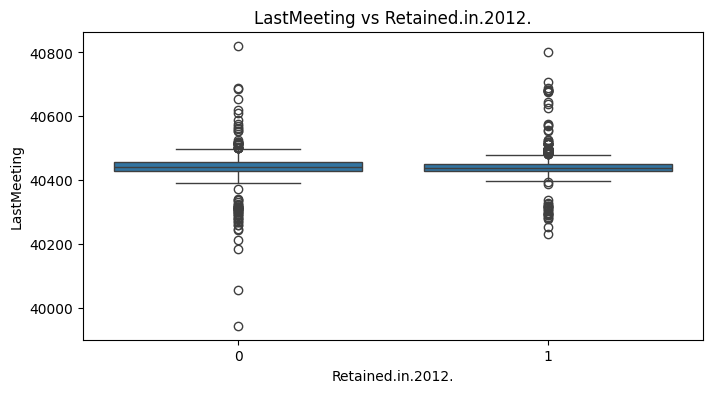

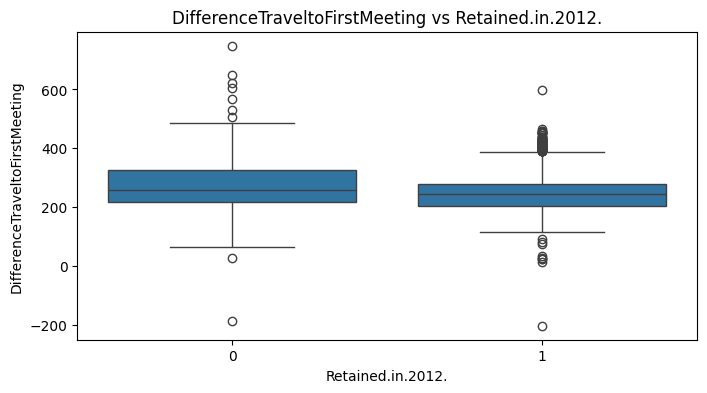

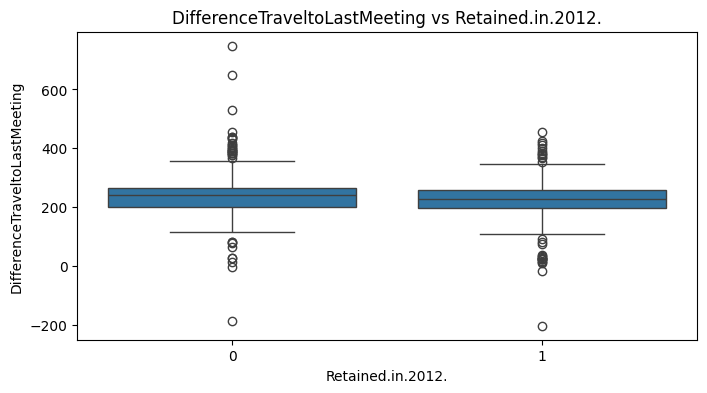

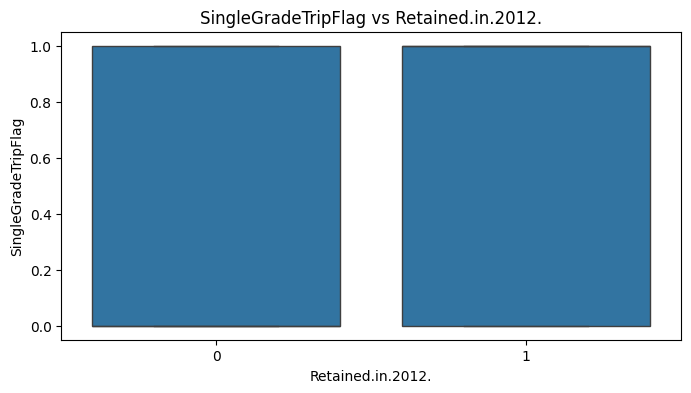

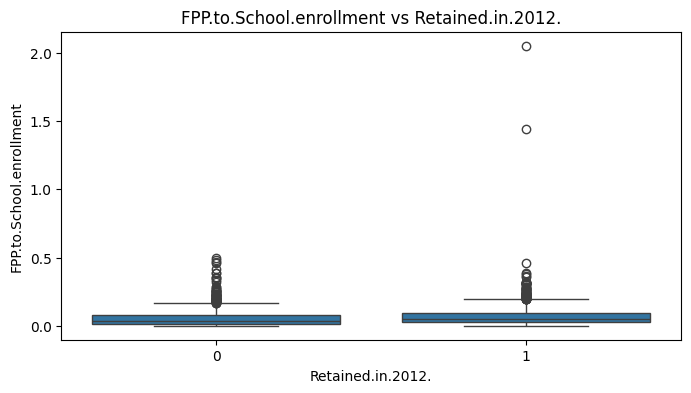

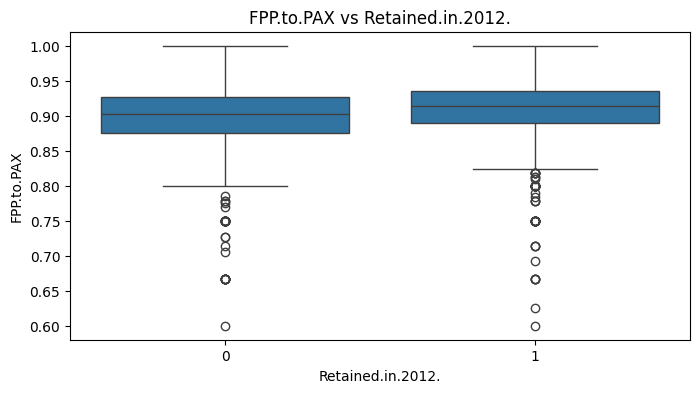

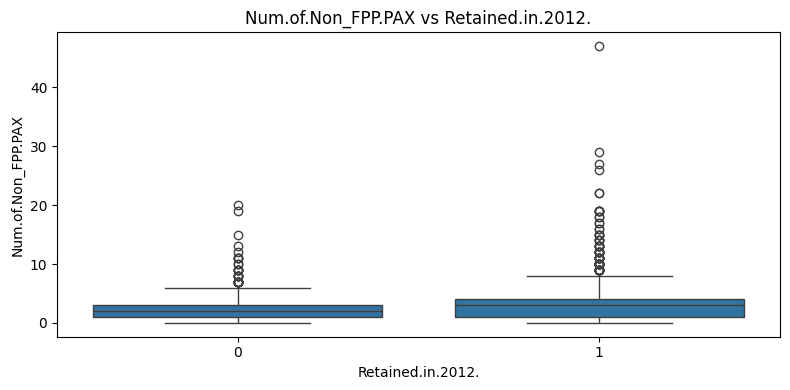

In [ ]:
#Variables numéricas vs objetivo
for col in num_cols:
    if col != target:
        plt.figure(figsize=(8,4))
        sns.boxplot(data=df, x=target, y=col)
        plt.title(f"{col} vs {target}")
plt.tight_layout()
plt.show()

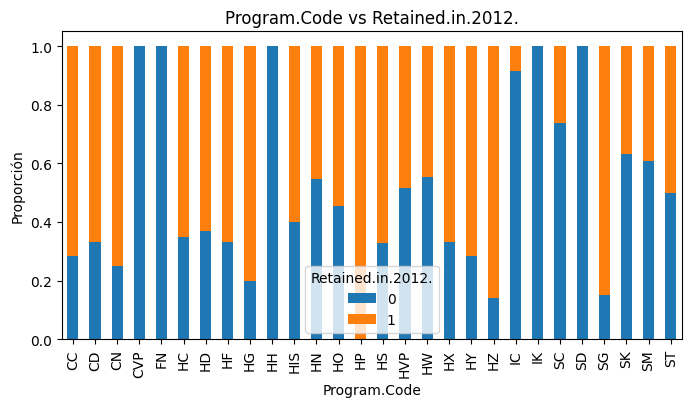

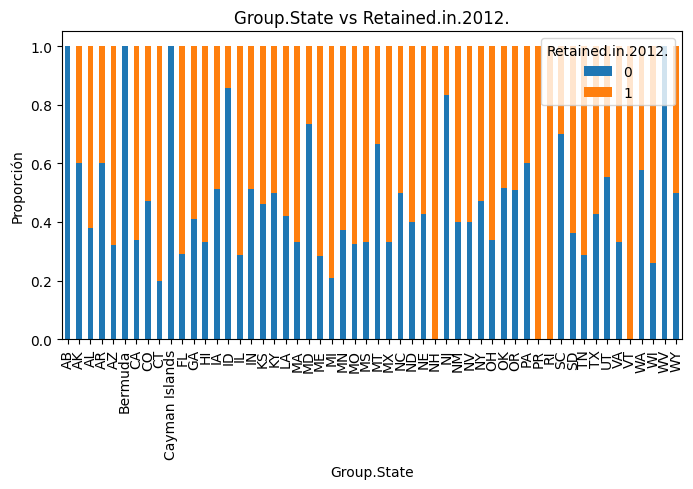

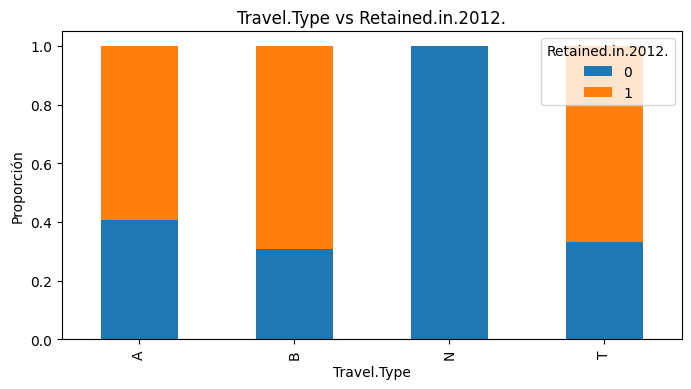

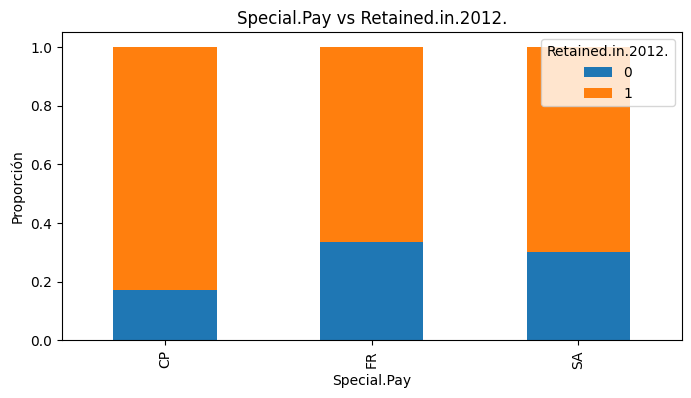

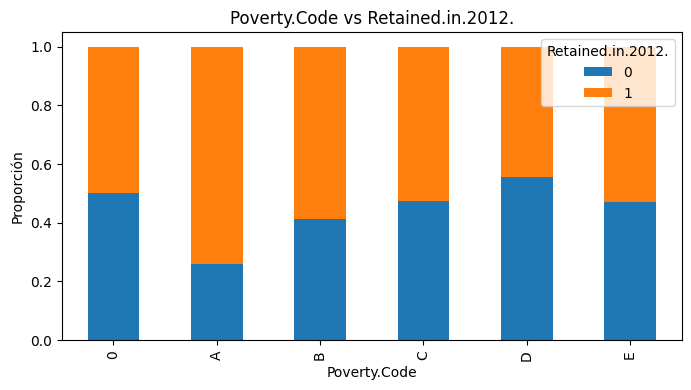

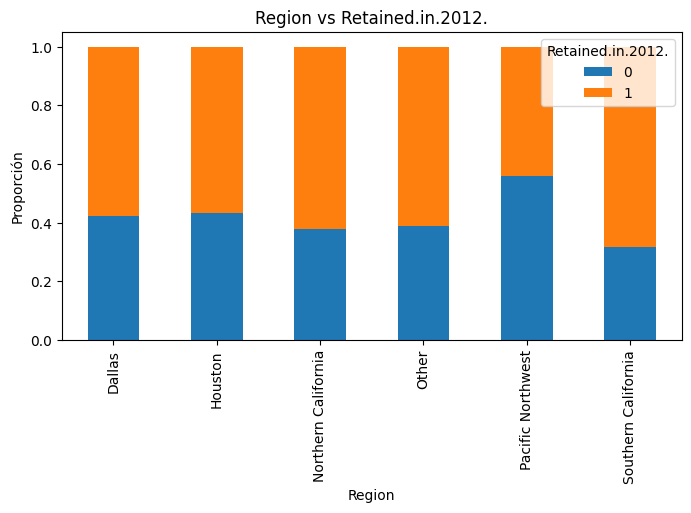

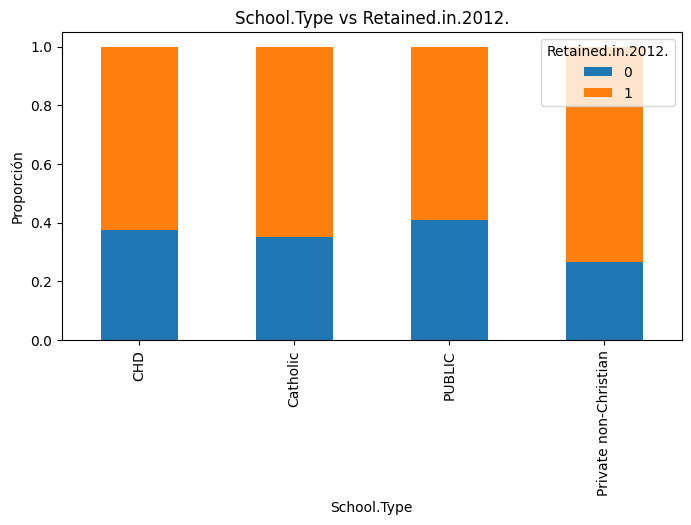

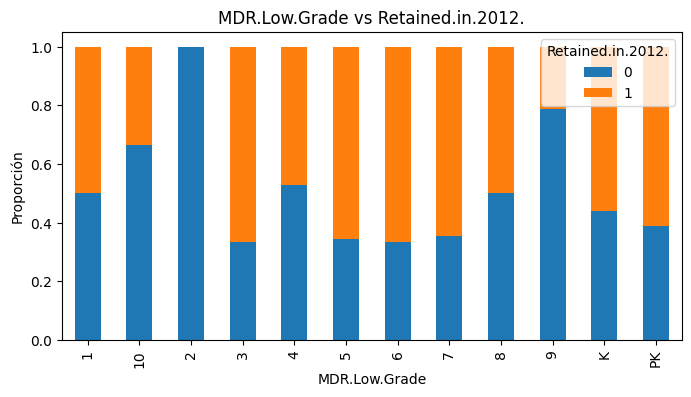

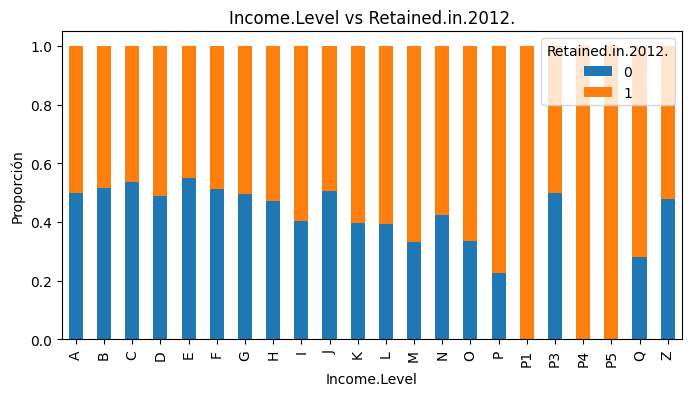

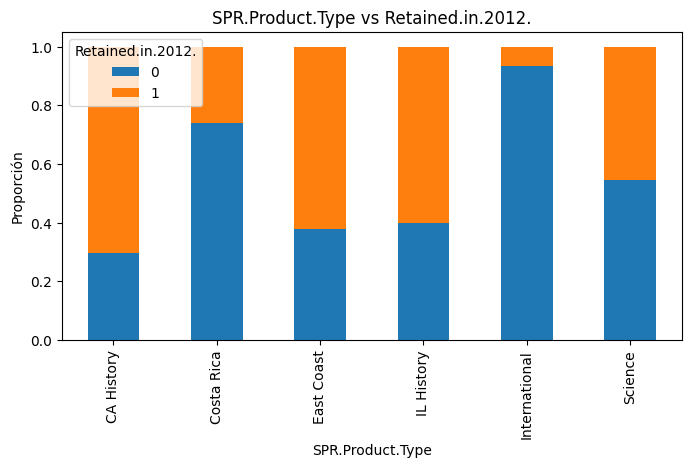

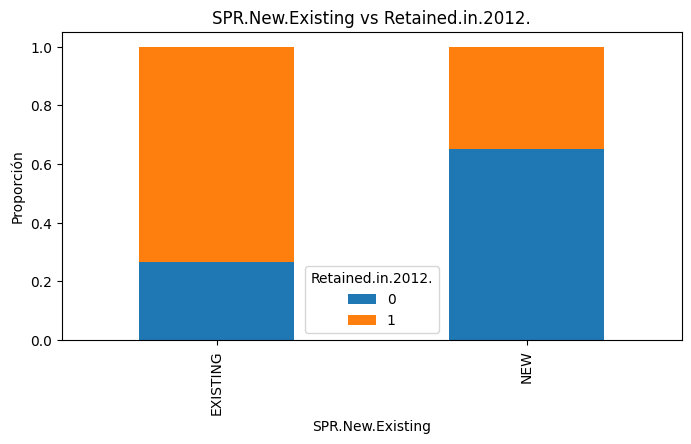

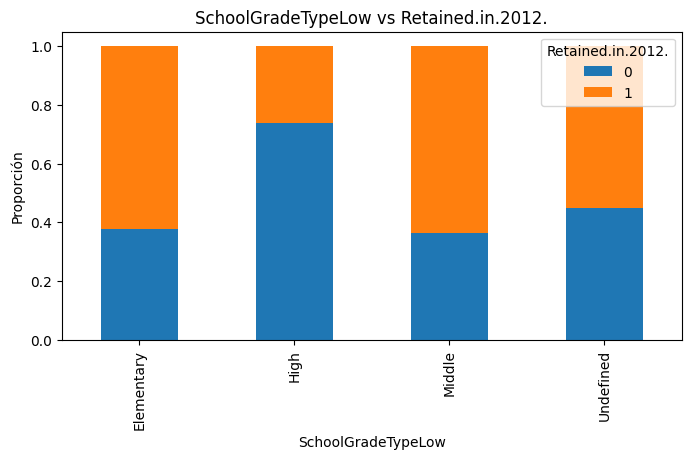

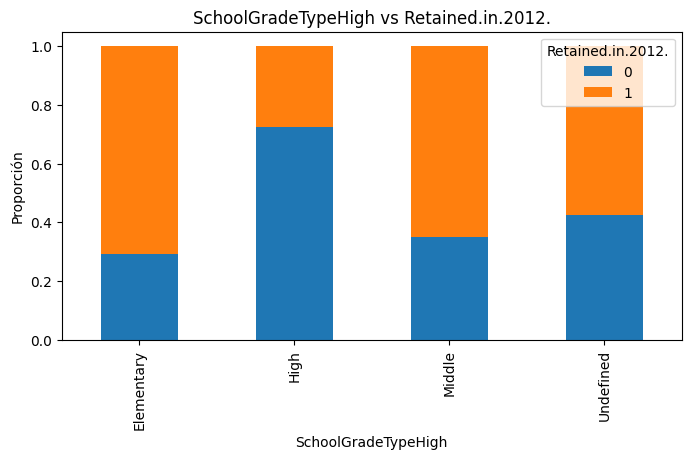

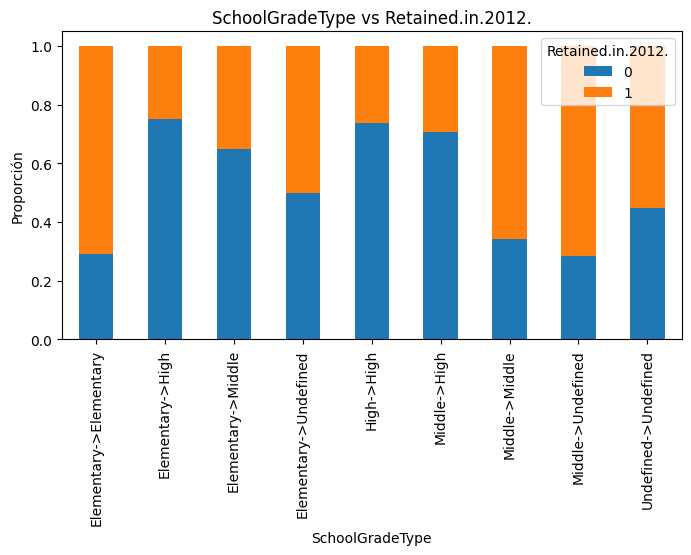

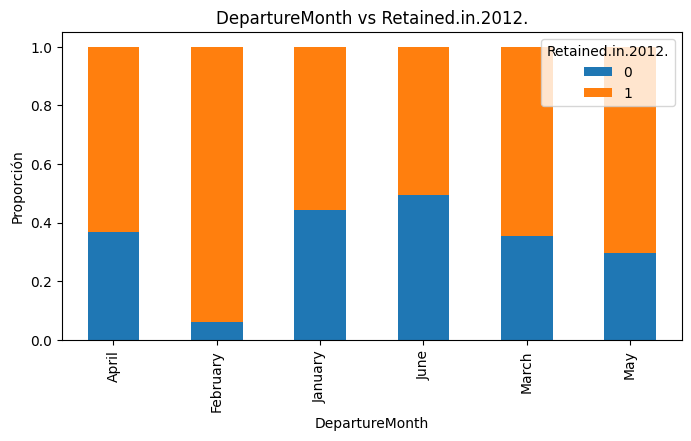

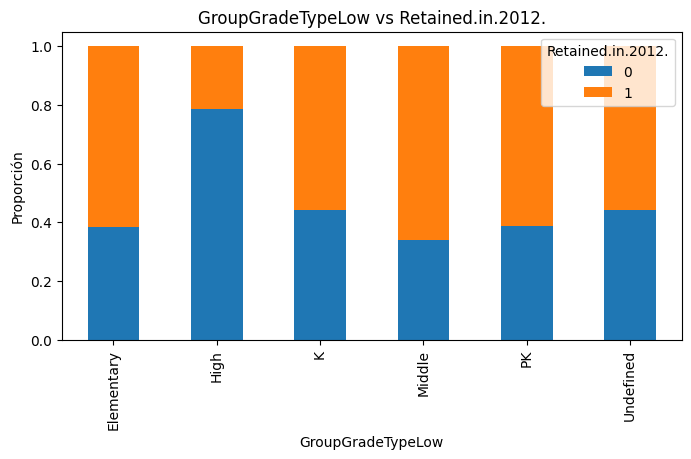

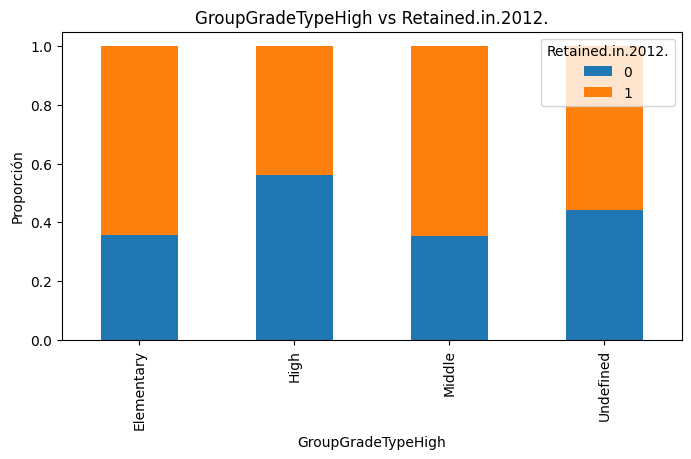

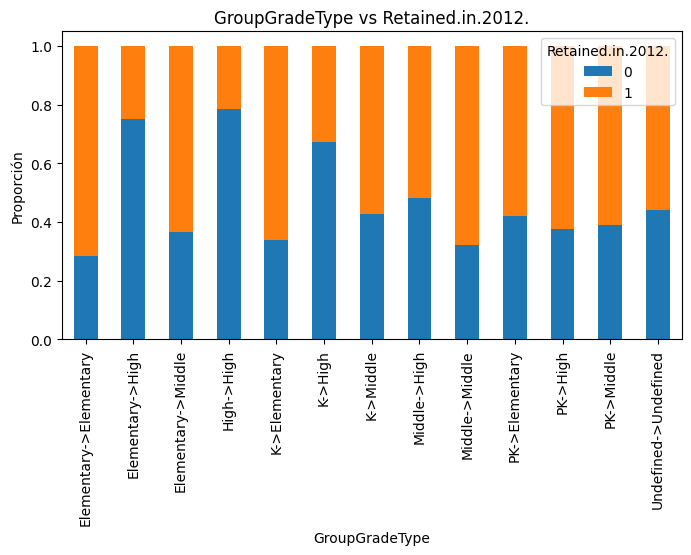

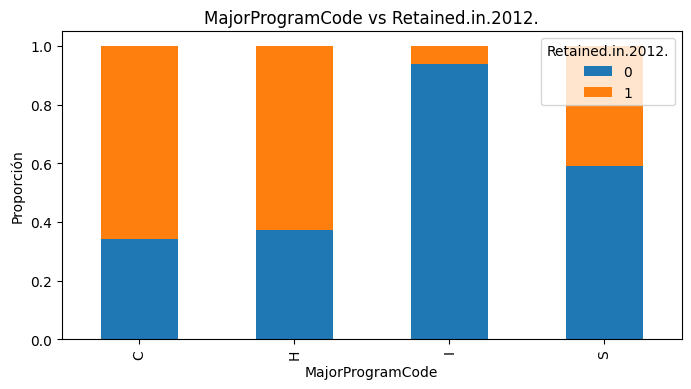

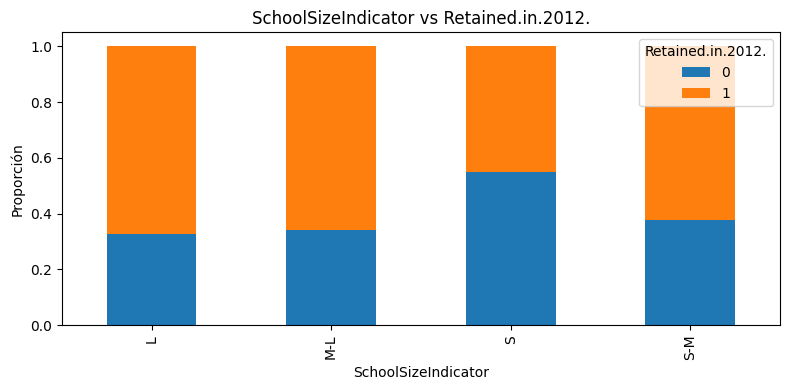

In [ ]:
# Analisis de variables no numéricas vs objetivo
for col in cat_cols:
    if col != target:
        ct = pd.crosstab(df[col], df[target], normalize="index")
        ct.plot(kind="bar", stacked=True, figsize=(8,4))
        plt.title(f"{col} vs {target}")
        plt.ylabel("Proporción")
plt.tight_layout()
plt.show()

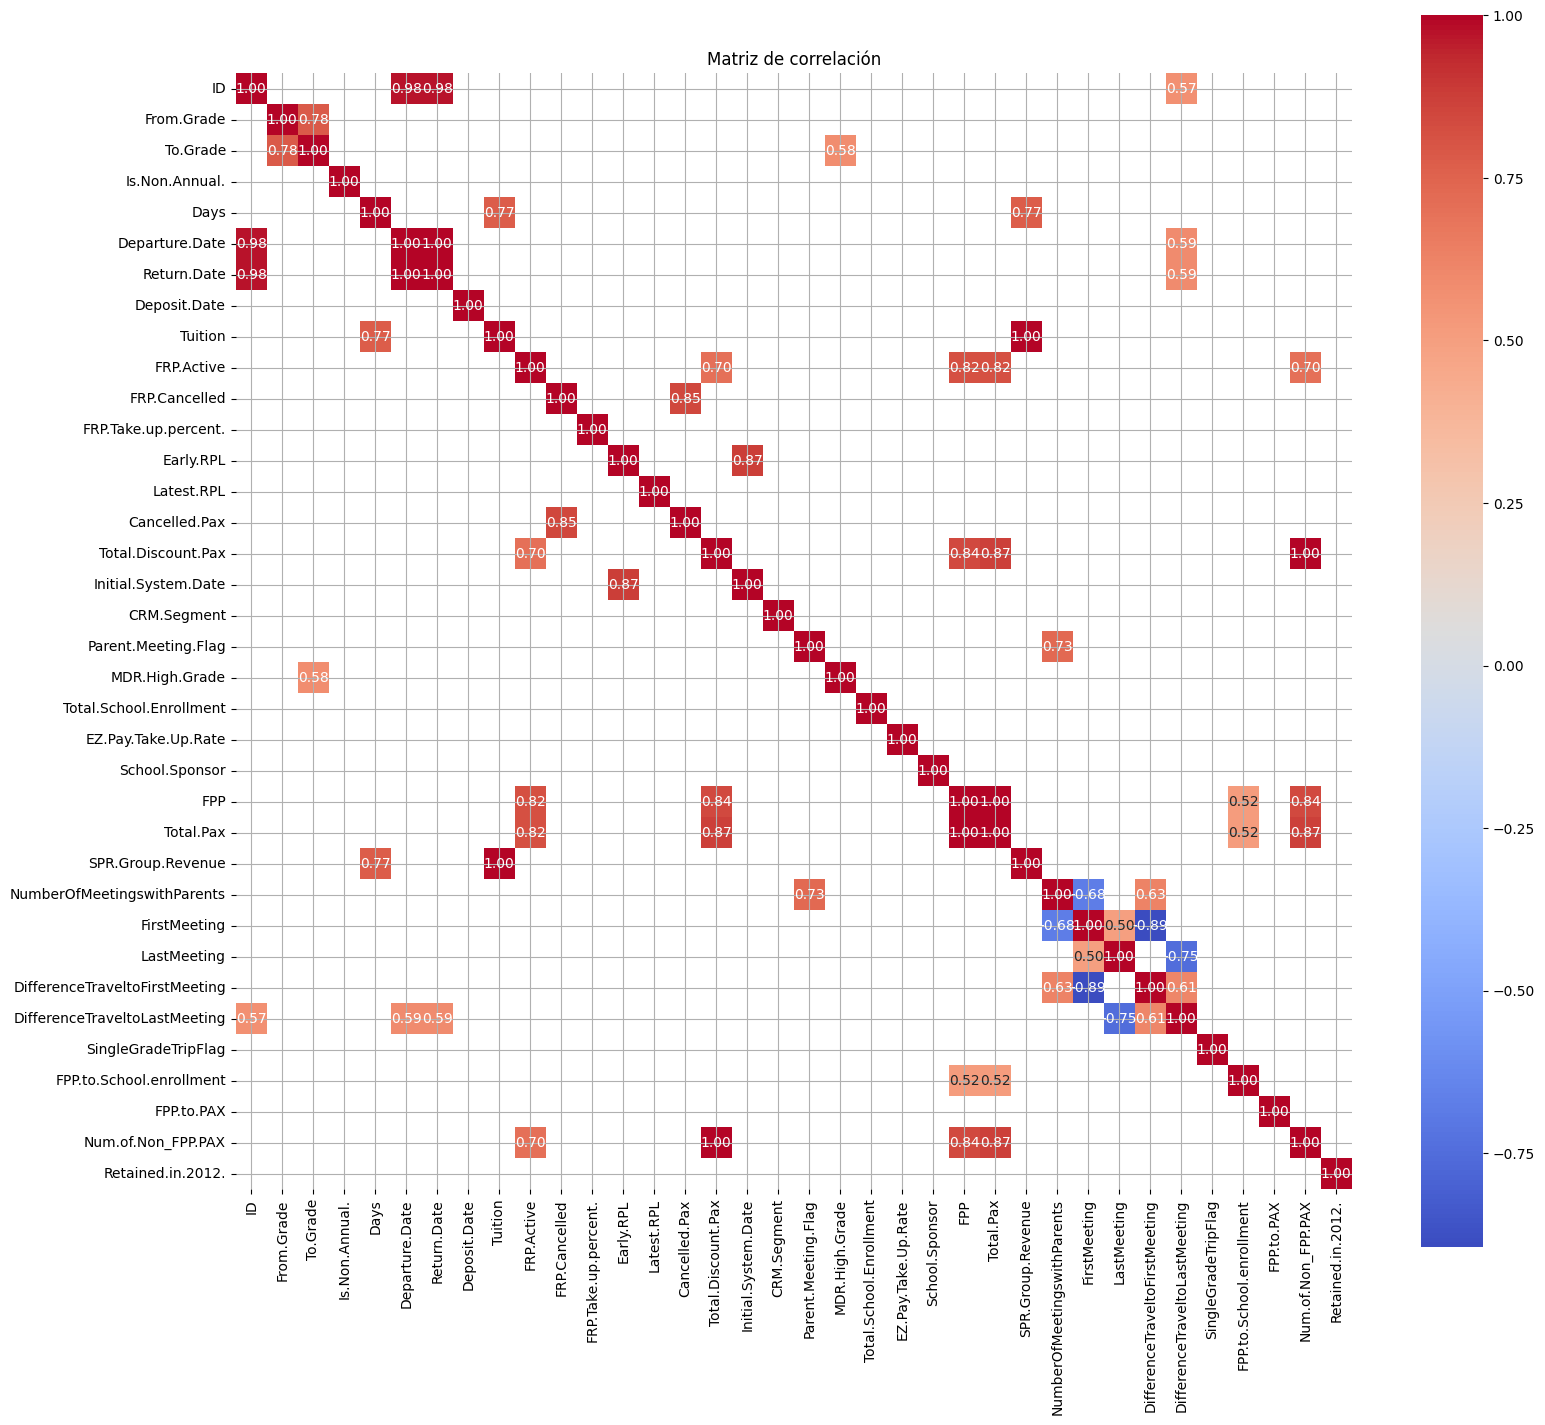

In [ ]:
# Matriz de correlación
matrix = df[num_cols].corr()

filtered_matrix=matrix.copy()
filtered_matrix[np.abs(filtered_matrix)<=0.5]=np.nan

plt.figure(figsize=(18,16))
plt.grid(True)
sns.heatmap(filtered_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, mask=filtered_matrix.isnull())
plt.title("Matriz de correlación")
plt.show()

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers detectados")

From.Grade: 325 outliers detectados
To.Grade: 593 outliers detectados
Is.Non.Annual.: 368 outliers detectados
Days: 328 outliers detectados
Deposit.Date: 197 outliers detectados
Tuition: 15 outliers detectados
FRP.Active: 107 outliers detectados
FRP.Cancelled: 199 outliers detectados
FRP.Take.up.percent.: 131 outliers detectados
Early.RPL: 35 outliers detectados
Latest.RPL: 364 outliers detectados
Cancelled.Pax: 145 outliers detectados
Total.Discount.Pax: 96 outliers detectados
Initial.System.Date: 97 outliers detectados
Parent.Meeting.Flag: 337 outliers detectados
MDR.High.Grade: 662 outliers detectados
Total.School.Enrollment: 67 outliers detectados
EZ.Pay.Take.Up.Rate: 47 outliers detectados
School.Sponsor: 253 outliers detectados
FPP: 111 outliers detectados
Total.Pax: 117 outliers detectados
SPR.Group.Revenue: 15 outliers detectados
NumberOfMeetingswithParents: 918 outliers detectados
FirstMeeting: 509 outliers detectados
LastMeeting: 193 outliers detectados
DifferenceTraveltoFirs

##3. Cleaning Data

In [ ]:
#1. Converting data types
excel_dates = ["Departure.Date","Return.Date","Deposit.Date",
               "Early.RPL","Latest.RPL","FirstMeeting","LastMeeting","Initial.System.Date"]

for c in excel_dates:
    if c in df.columns:
        # si viene numérica: tratamos como serial de Excel
        if pd.api.types.is_numeric_dtype(df[c]):
            df[c] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df[c], unit="D")
        else:
            df[c] = pd.to_datetime(df[c], errors="coerce")

In [ ]:
#1.1 Convertir la numéricas que pueden ser binarias y las que no, se mantienen numéricas
keep_num = ["Days","Tuition","FPP","Total.Pax","Total.School.Enrollment",
            "FRP.Active","FRP.Cancelled","Cancelled.Pax","Total.Discount.Pax",
            "FPP.to.PAX","FPP.to.School.enrollment","SPR.Group.Revenue",
            "DifferenceTraveltoFirstMeeting","DifferenceTraveltoLastMeeting",
            "From.Grade","To.Grade","MDR.Low.Grade","MDR.High.Grade",
            "NumberOfMeetingswithParents","EZ.Pay.Take.Up.Rate"]

for c in keep_num:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# banderas 0/1
for c in ["Is.Non.Annual.","Parent.Meeting.Flag","School.Sponsor","SingleGradeTripFlag"]:
    if c in df.columns:
        df[c] = df[c].astype("int64")

In [ ]:
#2 Convertir a categóricas las que son categóricas
cat_cols = ["Program.Code","Group.State","Travel.Type","Special.Pay","Poverty.Code",
            "Income.Level","CRM.Segment","Region","SchoolSizeIndicator","SPR.New.Existing"]

for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("string").str.strip().astype("category")

### 3.1 Feature Engineering

In [ ]:
#Creacion de variables adicionales para eliminar algunas de fecha (no dicen mucho)
if {"Early.RPL","Latest.RPL","Departure.Date"}.issubset(df.columns):
    df["Has_EarlyRPL"]  = df["Early.RPL"].notna().astype(int)
    df["Has_LatestRPL"] = df["Latest.RPL"].notna().astype(int)
    df["Days_before_departure_EarlyRPL"]  = (df["Departure.Date"] - df["Early.RPL"]).dt.days
    df["Days_before_departure_LatestRPL"] = (df["Departure.Date"] - df["Latest.RPL"]).dt.days

### 3.2 Imputing missing data

In [ ]:
if "Special.Pay" in df.columns:
    df["Special.Pay"] = df["Special.Pay"].cat.add_categories(["Standard"]).fillna("Standard") #Contexto del problema

for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].cat.add_categories(["Missing"]).fillna("Missing")

# numéricas (mediana + indicador)
for c in keep_num:
    if c in df.columns and df[c].isna().any():
        df[c+"_imputed"] = df[c].isna().astype(int)
        df[c] = df[c].fillna(df[c].median())

### 3.3 Dataset check before modeling

In [ ]:
df.head()

,ID,Program.Code,From.Grade,To.Grade,Group.State,Is.Non.Annual.,Days,Travel.Type,Departure.Date,Return.Date,...,Days_before_departure_EarlyRPL,Days_before_departure_LatestRPL,Total.School.Enrollment_imputed,FPP.to.School.enrollment_imputed,DifferenceTraveltoFirstMeeting_imputed,DifferenceTraveltoLastMeeting_imputed,From.Grade_imputed,To.Grade_imputed,MDR.Low.Grade_imputed,MDR.High.Grade_imputed
0,1,HS,4.0,4.0,CA,0,1,A,2011-01-14,2011-01-14,...,291.0,155.0,0,0,0,0,0,0,1,0
1,2,HC,8.0,8.0,AZ,0,7,A,2011-01-14,2011-01-21,...,451.0,157.0,0,0,0,0,0,0,0,0
2,3,HD,8.0,8.0,FL,0,3,A,2011-01-15,2011-01-17,...,261.0,152.0,0,0,0,0,0,0,0,0
3,4,HN,9.0,12.0,VA,1,3,B,2011-01-15,2011-01-17,...,NaN,NaN,1,1,1,1,0,0,1,1
4,5,HD,6.0,8.0,FL,0,6,T,2011-01-16,2011-01-21,...,293.0,157.0,0,0,0,0,0,0,0,0


In [ ]:
for col in df.columns:
    if df[col].isna().any():
        print(f"Valores nulos en {col}: {df[col].isna().sum()}")

Valores nulos en Early.RPL: 673
Valores nulos en Latest.RPL: 19
Valores nulos en Initial.System.Date: 8
Valores nulos en FirstMeeting: 337
Valores nulos en LastMeeting: 337
Valores nulos en Days_before_departure_EarlyRPL: 673
Valores nulos en Days_before_departure_LatestRPL: 19


In [ ]:
#Imputar los nulos de las Days_before...
time_diff_cols = [
    "Days_before_departure_EarlyRPL","Days_before_departure_LatestRPL",
    "DifferenceTraveltoFirstMeeting","DifferenceTraveltoLastMeeting"
    ]
for col in time_diff_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

#Como hay valores nulos en las fechas y ya se tienen los días de diferencia (info más relevante), se eliminan estas variables
drop_date_cols = [
    "Early.RPL", "Latest.RPL","Initial.System.Date",
    "FirstMeeting", "LastMeeting","Departure.Date",
    "Return.Date", "Deposit.Date"
    ]

df_cleaned = df.drop(columns=[c for c in drop_date_cols if c in df.columns]).copy()

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Data columns (total 60 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   ID                                      2389 non-null   int64   
 1   Program.Code                            2389 non-null   category
 2   From.Grade                              2389 non-null   float64 
 3   To.Grade                                2389 non-null   float64 
 4   Group.State                             2389 non-null   category
 5   Is.Non.Annual.                          2389 non-null   int64   
 6   Days                                    2389 non-null   int64   
 7   Travel.Type                             2389 non-null   category
 8   Special.Pay                             2389 non-null   category
 9   Tuition                                 2389 non-null   int64   
 10  FRP.Active                              2389 non

### 3.4 One-hot encoding

In [ ]:
categorical_cols = [
    "Program.Code", "Group.State", "Travel.Type", "Special.Pay","Poverty.Code", "Region", "CRM.Segment", "School.Type",
    "SPR.Product.Type", "SPR.New.Existing", "Income.Level","SchoolGradeTypeLow", "SchoolGradeTypeHigh", "SchoolGradeType",
    "DepartureMonth", "GroupGradeTypeLow", "GroupGradeTypeHigh","GroupGradeType", "MajorProgramCode", "SchoolSizeIndicator"
]

# one hot encoding
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
df_encoded.info()

(2389, 231)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Columns: 231 entries, ID to SchoolSizeIndicator_Missing
dtypes: bool(191), float64(13), int64(27)
memory usage: 1.2 MB


In [ ]:
pd.options.display.max_columns = None # remove the limit on the number of columns by default only 20 are shows

df_encoded.head() #--> 233 columnas

,ID,From.Grade,To.Grade,Is.Non.Annual.,Days,Tuition,FRP.Active,FRP.Cancelled,FRP.Take.up.percent.,Cancelled.Pax,Total.Discount.Pax,Parent.Meeting.Flag,MDR.Low.Grade,MDR.High.Grade,Total.School.Enrollment,EZ.Pay.Take.Up.Rate,School.Sponsor,FPP,Total.Pax,SPR.Group.Revenue,NumberOfMeetingswithParents,DifferenceTraveltoFirstMeeting,DifferenceTraveltoLastMeeting,SingleGradeTripFlag,FPP.to.School.enrollment,FPP.to.PAX,Num.of.Non_FPP.PAX,Retained.in.2012.,Has_EarlyRPL,Has_LatestRPL,Days_before_departure_EarlyRPL,Days_before_departure_LatestRPL,Total.School.Enrollment_imputed,FPP.to.School.enrollment_imputed,DifferenceTraveltoFirstMeeting_imputed,DifferenceTraveltoLastMeeting_imputed,From.Grade_imputed,To.Grade_imputed,MDR.Low.Grade_imputed,MDR.High.Grade_imputed,Program.Code_CD,Program.Code_CN,Program.Code_CVP,Program.Code_FN,Program.Code_HC,Program.Code_HD,Program.Code_HF,Program.Code_HG,Program.Code_HH,Program.Code_HIS,Program.Code_HN,Program.Code_HO,Program.Code_HP,Program.Code_HS,Program.Code_HVP,Program.Code_HW,Program.Code_HX,Program.Code_HY,Program.Code_HZ,Program.Code_IC,Program.Code_IK,Program.Code_SC,Program.Code_SD,Program.Code_SG,Program.Code_SK,Program.Code_SM,Program.Code_ST,Program.Code_Missing,Group.State_AK,Group.State_AL,Group.State_AR,Group.State_AZ,Group.State_Bermuda,Group.State_CA,Group.State_CO,Group.State_CT,Group.State_Cayman Islands,Group.State_FL,Group.State_GA,Group.State_HI,Group.State_IA,Group.State_ID,Group.State_IL,Group.State_IN,Group.State_KS,Group.State_KY,Group.State_LA,Group.State_MA,Group.State_MD,Group.State_ME,Group.State_MI,Group.State_MN,Group.State_MO,Group.State_MS,Group.State_MT,Group.State_MX,Group.State_NC,Group.State_ND,Group.State_NE,Group.State_NH,Group.State_NJ,Group.State_NM,Group.State_NV,Group.State_NY,Group.State_OH,Group.State_OK,Group.State_OR,Group.State_PA,Group.State_PR,Group.State_RI,Group.State_SC,Group.State_SD,Group.State_TN,Group.State_TX,Group.State_UT,Group.State_VA,Group.State_VT,Group.State_WA,Group.State_WI,Group.State_WV,Group.State_WY,Group.State_Missing,Travel.Type_B,Travel.Type_N,Travel.Type_T,Travel.Type_Missing,Special.Pay_FR,Special.Pay_SA,Special.Pay_Standard,Special.Pay_Missing,Poverty.Code_A,Poverty.Code_B,Poverty.Code_C,Poverty.Code_D,Poverty.Code_E,Poverty.Code_Missing,Region_Houston,Region_Northern California,Region_Other,Region_Pacific Northwest,Region_Southern California,Region_Missing,CRM.Segment_10.0,CRM.Segment_11.0,CRM.Segment_2.0,CRM.Segment_3.0,CRM.Segment_4.0,CRM.Segment_5.0,CRM.Segment_6.0,CRM.Segment_7.0,CRM.Segment_8.0,CRM.Segment_9.0,CRM.Segment_Missing,School.Type_Catholic,School.Type_PUBLIC,School.Type_Private non-Christian,SPR.Product.Type_Costa Rica,SPR.Product.Type_East Coast,SPR.Product.Type_IL History,SPR.Product.Type_International,SPR.Product.Type_Science,SPR.New.Existing_NEW,SPR.New.Existing_Missing,Income.Level_B,Income.Level_C,Income.Level_D,Income.Level_E,Income.Level_F,Income.Level_G,Income.Level_H,Income.Level_I,Income.Level_J,Income.Level_K,Income.Level_L,Income.Level_M,Income.Level_N,Income.Level_O,Income.Level_P,Income.Level_P1,Income.Level_P3,Income.Level_P4,Income.Level_P5,Income.Level_Q,Income.Level_Z,Income.Level_Missing,SchoolGradeTypeLow_High,SchoolGradeTypeLow_Middle,SchoolGradeTypeLow_Undefined,SchoolGradeTypeHigh_High,SchoolGradeTypeHigh_Middle,SchoolGradeTypeHigh_Undefined,SchoolGradeType_Elementary->High,SchoolGradeType_Elementary->Middle,SchoolGradeType_Elementary->Undefined,SchoolGradeType_High->High,SchoolGradeType_Middle->High,SchoolGradeType_Middle->Middle,SchoolGradeType_Middle->Undefined,SchoolGradeType_Undefined->Undefined,DepartureMonth_February,DepartureMonth_January,DepartureMonth_June,DepartureMonth_March,DepartureMonth_May,GroupGradeTypeLow_High,GroupGradeTypeLow_K,GroupGradeTypeLow_Middle,GroupGradeTypeLow_PK,GroupGradeTypeLow_Undefined,GroupGradeTypeHigh_High,GroupGradeTypeHigh_Middle,GroupGradeTypeHigh_Undefined,GroupGradeType_Elementary->High,GroupGradeType_Elementary->Middle,GroupGradeType_High

##4. Data preparation

In [ ]:
y=df_encoded["Retained.in.2012."]
X=df_encoded.drop(columns=["Retained.in.2012."])

In [ ]:
y.describe()

,Retained.in.2012.
count,2389.000000
mean,0.607367
std,0.488439
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
# For "apples-to-apples" comparisons, set a starting value ("seed") for the random number generator
np.random.seed(77300)

# split the data randomly into 80% train and 20% test samples
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20, stratify=y) #Train (60% 1, 40% 0), Test (60% 1, 40% 0)
# IMPORTANT: these samples are stratified, i.e., the proportion of retained and not-retained customers is the same in both

# Lets check the results
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1911, 230)
(478, 230)
(1911,)
(478,)


## 5. Modeling

In [ ]:
# First we define a set of functions to compute the metrics of the model

# ROC curve
def plot_roc(y_test, y_pred):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1, drop_intermediate = False)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([-0.001, 1.001])
    plt.ylim([-0.001, 1.001])
    plt.xlabel('1-Specificity (False Negative Rate)')
    plt.ylabel('Sensitivity (True Positive Rate)')
    plt.title('ROC curve')
    plt.legend(loc="lower right")
    plt.show()

# Confusion Matrix returns in the format: cm[0,0], cm[0,1], cm[1,0], cm[1,1]: tn, fp, fn, tp

# Sensitivity
def custom_sensitivity_score(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    return (tp/(tp+fn))

# Specificity
def custom_specificity_score(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    return (tn/(tn+fp))

# Positive Predictive Value
def custom_ppv_score(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    return (tp/(tp+fp))

# Negative Predictive Value
def custom_npv_score(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    return (tn/(tn+fn))

# Accuracy
def custom_accuracy_score(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    return ((tn+tp)/(tn+tp+fn+fp))

In [ ]:
svm_estimators = []
svm_estimators.append(('standardize', StandardScaler())) # scale the data
svm_estimators.append(('SVM', svm.SVC(probability=True))) # define SVM with probabilities (recall, SVM be default does not predict probabilities)

# Define the support vectors machine model and call it classifier_SVM
Classifier_SVM = Pipeline(svm_estimators, verbose=False)

# Train the model classifier_SVM on the training data
Classifier_SVM.fit(X_train, y_train)

Pipeline(steps=[('standardize', StandardScaler()),
                ('SVM', SVC(probability=True))])

Metrics of the Support Vector Machines model: 

Confusion matrix: 
[[142  57]
 [ 46 233]]
                                   Accuracy: 0.7845188284518828
                   SENSITIVITY (aka RECALL): 0.803448275862069
                 SPECIFICITY (aka FALL-OUT): 0.7553191489361702
 POSITIVE PREDICTIVE VALUE, (aka PRECISION): 0.8351254480286738
                 NEGATIVE PREDICTIVE VALUE): 0.7135678391959799


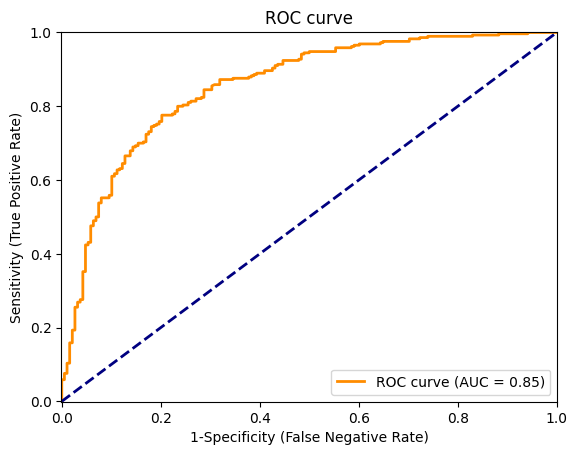

 AUC: 0.8541177549523111


In [ ]:
# Select the threshold value -- we will use Т=0.6073. Why? Why not 50%? Because 60.73% -- is the average probability of retention in our data (1451 "1"s out of 2389 datapoints)
class_threshold = 0.6073

# use the fitted model to predict the testing data
y_pred_prob = Classifier_SVM.predict_proba(X_test)[:,1] # probabilities
y_pred = np.where(y_pred_prob > class_threshold, 1, 0) # classification

# Lets look at the model metrics

print('Metrics of the Support Vector Machines model: \n')

cm = np.transpose(confusion_matrix(y_test, y_pred))
print("Confusion matrix: \n" + str(cm))

print("                                   Accuracy: " + str(custom_accuracy_score(y_test, y_pred)))
print("                   SENSITIVITY (aka RECALL): " + str(custom_sensitivity_score(y_test, y_pred)))
print("                 SPECIFICITY (aka FALL-OUT): " + str(custom_specificity_score(y_test, y_pred)))
print(" POSITIVE PREDICTIVE VALUE, (aka PRECISION): " + str(custom_ppv_score(y_test, y_pred)))
print("                 NEGATIVE PREDICTIVE VALUE): " + str(custom_npv_score(y_test, y_pred)))

plot_roc(y_test, y_pred_prob)
print(" AUC: " + str(roc_auc_score(y_test, y_pred_prob)))

##6. Hyperparamter tuning - GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [ ]:
steps = [("scaler", StandardScaler()), ('SVM', svm.SVC(probability = True))]
pipeline = Pipeline(steps)

In [ ]:
# Selección de la métrica que queremos mejorar
#roc_auc_score
from sklearn.metrics import accuracy_score
score_func = make_scorer(accuracy_score, greater_is_better = True)

In [ ]:
# Definir la variación de los hiperparametros
param_grid = {'SVM__C': [0.1, 1, 10],
              'SVM__kernel': ['linear', 'rbf' , 'poly'] #
            }

In [ ]:
# Grid search - Uniobjetivo
grid = GridSearchCV(pipeline, param_grid = param_grid, cv = 5, scoring = score_func, refit = True, verbose = 3, return_train_score = True)

In [ ]:
grid_search = grid.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END SVM__C=0.1, SVM__kernel=linear;, score=(train=0.838, test=0.783) total time=   1.3s
[CV 2/5] END SVM__C=0.1, SVM__kernel=linear;, score=(train=0.836, test=0.780) total time=   1.3s
[CV 3/5] END SVM__C=0.1, SVM__kernel=linear;, score=(train=0.836, test=0.791) total time=   1.3s
[CV 4/5] END SVM__C=0.1, SVM__kernel=linear;, score=(train=0.848, test=0.759) total time=   1.2s
[CV 5/5] END SVM__C=0.1, SVM__kernel=linear;, score=(train=0.832, test=0.796) total time=   1.3s
[CV 1/5] END SVM__C=0.1, SVM__kernel=rbf;, score=(train=0.643, test=0.634) total time=   1.4s
[CV 2/5] END SVM__C=0.1, SVM__kernel=rbf;, score=(train=0.639, test=0.620) total time=   2.2s
[CV 3/5] END SVM__C=0.1, SVM__kernel=rbf;, score=(train=0.638, test=0.623) total time=   2.4s
[CV 4/5] END SVM__C=0.1, SVM__kernel=rbf;, score=(train=0.648, test=0.636) total time=   1.4s
[CV 5/5] END SVM__C=0.1, SVM__kernel=rbf;, score=(train=0.634, test=0.636) tota

In [ ]:
print(grid_search.best_params_)
print(grid_search.best_estimator_)

{'SVM__C': 1, 'SVM__kernel': 'rbf'}
Pipeline(steps=[('scaler', StandardScaler()),
                ('SVM', SVC(C=1, probability=True))])


In [ ]:
grid_predictions = grid_search.predict(X_test)

In [ ]:
print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

           0       0.76      0.68      0.72       188
           1       0.81      0.86      0.83       290

    accuracy                           0.79       478
   macro avg       0.78      0.77      0.77       478
weighted avg       0.79      0.79      0.79       478



##7. Finishing the analyses

In [ ]:
# If we have the prediction data (e.g., about the new clients) the load and clean them first to obtain the X_pred matrix of exactly the same structure as X_train
# in our case there is no such data, so we will predict the testign data and export the resultant predictions
X_pred = X_test

# Which model should we take?

# Since the random forest model with optimized hyper-parameters obtained the higest AUC, lets take that; recall it is called grid_search_RF
y_pred_prob = grid_search.predict_proba(X_pred)[:,1]

# Lets add the ID column to know "who is who"
Prediction = pd.DataFrame(data={"ID":X_pred["ID"],"Predicted Probability":y_pred_prob})

# Export the predictions into a CSV file
Prediction.to_csv("Predicted Retention Probability_testing.csv",sep = ',')

# Creación de archivo para hacer predicciones con el mejor modelo

## Paso 1: Definición de los hiperparametros del Modelo Final

In [ ]:
modelo_final = pipeline.set_params(**grid_search.best_params_)
modelo_final.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('SVM', SVC(C=1, probability=True))])

## Paso 2: Almacenar modelo Final en un archivo (Serialización)

In [ ]:
from joblib import dump # libreria de serializacion

# grabar el pipeline de las transformaciones y el mejor modelo en un archivo .joblib
dump(modelo_final, 'modelo_SVM_final.joblib')

['modelo_SVM_final.joblib']

## Paso 3. Desde cualquier otro Jupiter o programa puedes cargar modelo Final y hacer predicciones

In [ ]:
from joblib import load # libreria de deserializacion

# cargar el pipeline del transformador y modelo desde un archivo
modelo_Final = load('modelo_SVM_final.joblib')

## Paso 4. Hacer predicciones en vivo con el mejor modelo

In [ ]:
predicciones_nuevas = modelo_Final.predict(X_test)
predicciones_nuevas

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,

In [ ]:
# Calculo de probabilidades
y_pred_prob = modelo_Final.predict_proba(X_pred)[:,1]
y_pred_prob

array([0.71971816, 0.41712949, 0.82287114, 0.95419059, 0.85208771,
       0.83906425, 0.89715539, 0.95459857, 0.84262635, 0.6011498 ,
       0.92458528, 0.73891131, 0.23091632, 0.91928682, 0.23178986,
       0.87928501, 0.13593253, 0.54274663, 0.42521177, 0.72064392,
       0.20163721, 0.7705806 , 0.93145548, 0.04637884, 0.89359635,
       0.67868903, 0.9433083 , 0.8857132 , 0.87331885, 0.18116156,
       0.33146889, 0.61580084, 0.52127304, 0.39246894, 0.79743063,
       0.84971372, 0.8162372 , 0.57683251, 0.85136763, 0.5361842 ,
       0.1696016 , 0.92393361, 0.54489978, 0.66337014, 0.07030836,
       0.92824568, 0.57452659, 0.90989802, 0.10769198, 0.68872336,
       0.67303026, 0.78882328, 0.255654  , 0.93553858, 0.89633582,
       0.12924424, 0.70305234, 0.7810562 , 0.83145273, 0.01775829,
       0.87092085, 0.47271217, 0.69265869, 0.11919821, 0.42779794,
       0.92514807, 0.38962629, 0.94289423, 0.87009368, 0.27765988,
       0.1930686 , 0.90179274, 0.51441137, 0.84126264, 0.91424